# NB01 - Doppler image waveform extraction

This notebook develops and validates an image-based Doppler ultrasound waveform extraction pipeline.

The objectives of this notebook are:

- load Doppler ultrasound video frames,
- define and validate the Doppler ROI,
- detect the Doppler baseline,
- automatically identify spectrum orientation,
- extract the Doppler velocity envelope,
- smooth the extracted waveform,
- detect peak systolic velocity (PSV) peaks,
- analyze beat-level waveform morphology,
- perform beat quality control,
- aggregate waveform features at recording level,
- validate the processing pipeline on Doppler recordings with different spectrum orientations.

The output of this notebook is a reusable image-processing pipeline that converts a Doppler spectrum image into waveform morphology features suitable for downstream analysis and future comparison with audio-derived signals.

## Imports and setup

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter, find_peaks, medfilt

## Exploratory image analysis

This section documents the initial exploratory work used to understand the Doppler image structure.

The code is intentionally kept as a development record. It shows how the ROI, Doppler mask, baseline, envelope, smoothing, PSV peaks, valleys, and local waveform morphology were inspected before the final processing functions were created.

The final reusable pipeline is defined in the following sections.

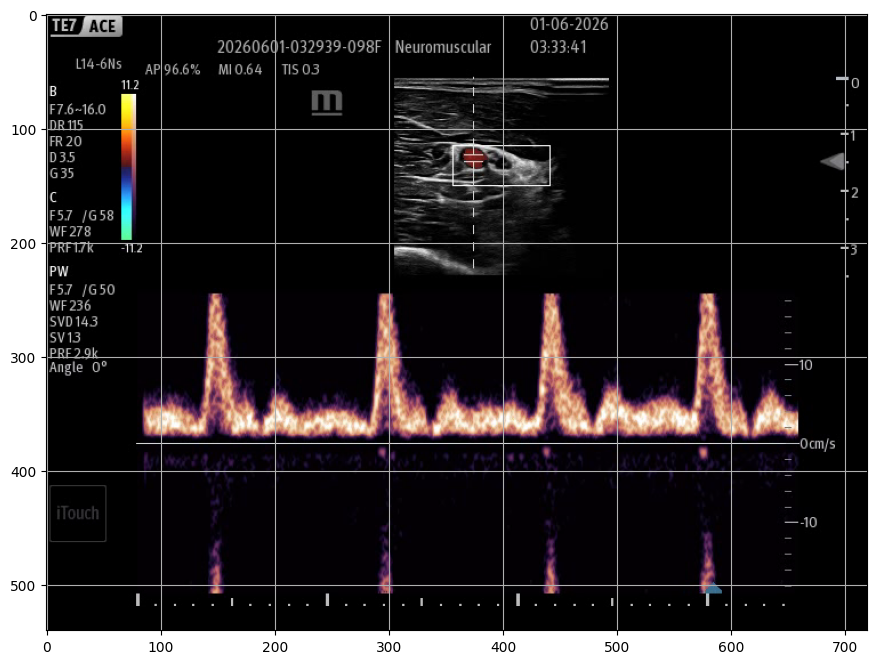

In [2]:
video_path_a = r"D:\code\DopplerLab\ultrasound_recordings\candidate.avi"
cap = cv2.VideoCapture(video_path_a)
cap.set(cv2.CAP_PROP_POS_FRAMES, 92)
ok, frame = cap.read()
cap.release()

if not ok:
    raise RuntimeError("Could not read frame.")
    
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.axis("on")
plt.grid()
plt.show()

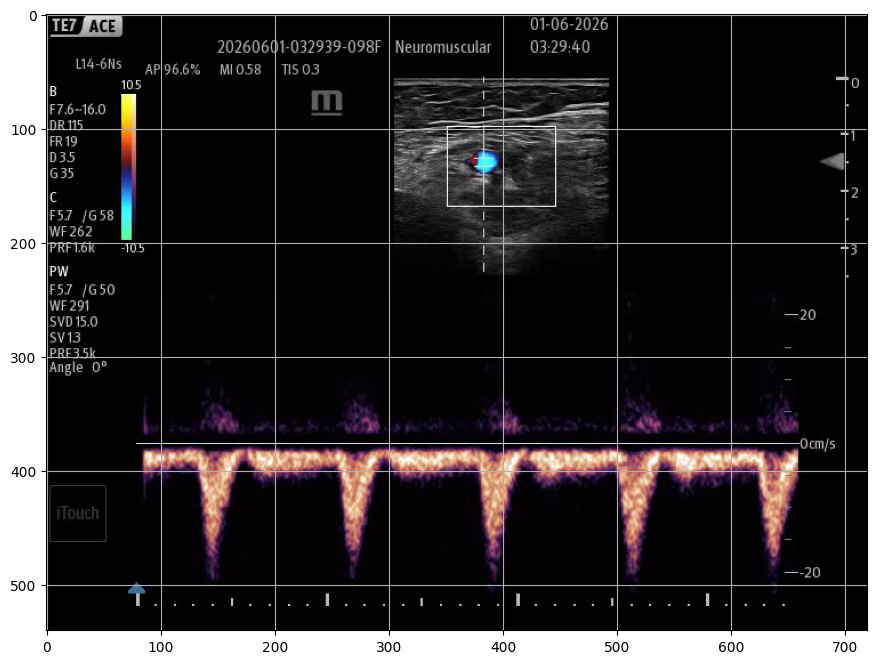

In [3]:
video_path_b = r"D:\code\DopplerLab\ultrasound_recordings\candidate_b.avi"
cap = cv2.VideoCapture(video_path_b)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read first frame from video_path_b")

frame_rgb_b = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb_b)
plt.axis("on")
plt.grid()
plt.show()

## Manual ROI selection

In this section, a rectangular ROI containing the Doppler spectrum is defined.

The coordinates `x_min`, `x_max`, `y_min`, and `y_max` are selected manually based on visual inspection of the Doppler frame.

The selected ROI is used in all subsequent processing steps.

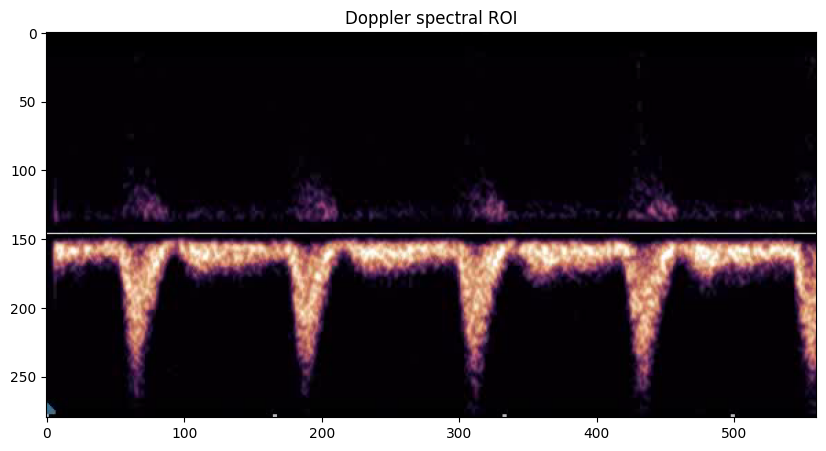

In [4]:
x_min, x_max = 80, 640
y_min, y_max = 230, 510

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
roi = frame_rgb[y_min:y_max, x_min:x_max]

plt.figure(figsize=(12, 5))
plt.imshow(roi)
plt.axis("on")
plt.title("Doppler spectral ROI")
plt.show()

## Doppler mask generation

In this section, the selected ROI is converted to grayscale and transformed into a binary Doppler mask.

Pixels exceeding a predefined intensity threshold are treated as Doppler signal candidates.

The resulting mask serves as the foundation for baseline detection, envelope extraction, and waveform reconstruction.

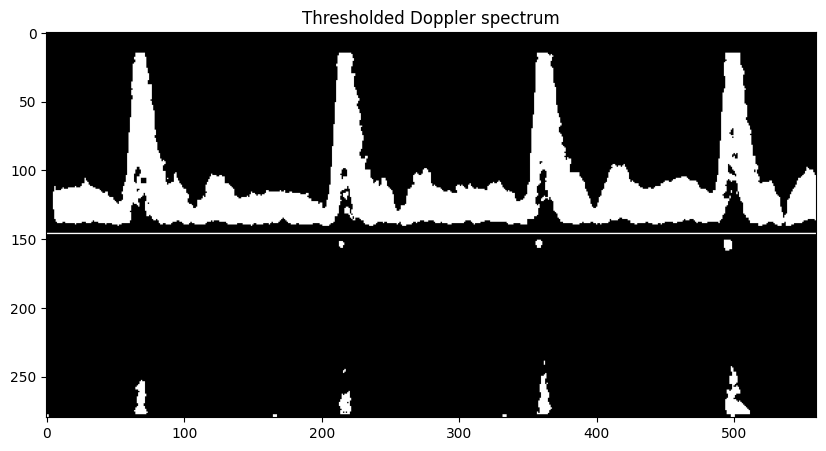

In [5]:
x_min, x_max = 80, 640
y_min, y_max = 230, 510

cap = cv2.VideoCapture(video_path_a)
cap.set(cv2.CAP_PROP_POS_FRAMES, 92)
ok, frame_a = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame_a, cv2.COLOR_BGR2RGB)
roi = frame_rgb[y_min:y_max, x_min:x_max]
gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
mask = gray > 80

plt.figure(figsize=(12,5))
plt.imshow(mask, cmap="gray")
plt.title("Thresholded Doppler spectrum")
plt.show()

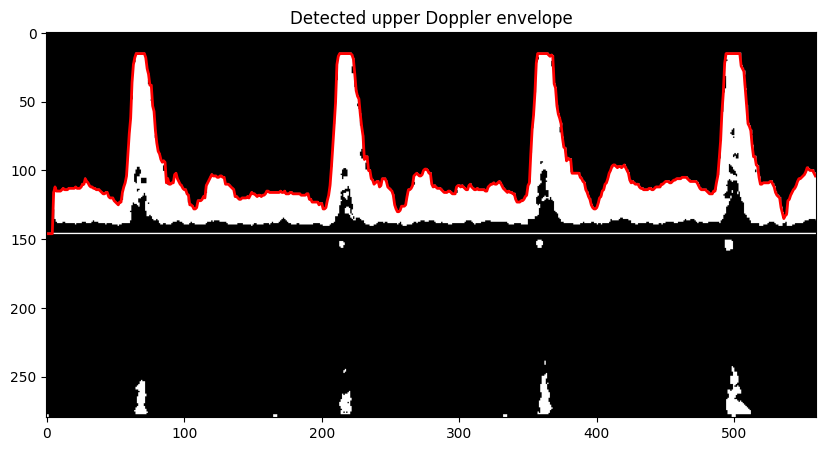

In [6]:
cap = cv2.VideoCapture(video_path_a)
cap.set(cv2.CAP_PROP_POS_FRAMES, 92)

ok, frame_b = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame_b, cv2.COLOR_BGR2RGB)

roi = frame_rgb[y_min:y_max, x_min:x_max]

gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)

mask = gray > 80

envelope = np.full(mask.shape[1], np.nan)

for x in range(mask.shape[1]):
    ys = np.where(mask[:, x])[0]

    if len(ys):
        envelope[x] = ys.min()

plt.figure(figsize=(14,5))
plt.imshow(mask, cmap="gray")
plt.plot(np.arange(len(envelope)), envelope, color="red", linewidth=2)
plt.title("Detected upper Doppler envelope")
plt.show()

##  Baseline detection

In this section, the Doppler baseline position is estimated.

The baseline is treated as a horizontal reference line from which the Doppler spectrum displacement is measured.

In the current exploratory approach, the baseline is identified as the image row containing the highest number of bright pixels within the Doppler mask.

This simple method is used to provide an initial reference for envelope extraction and waveform reconstruction.

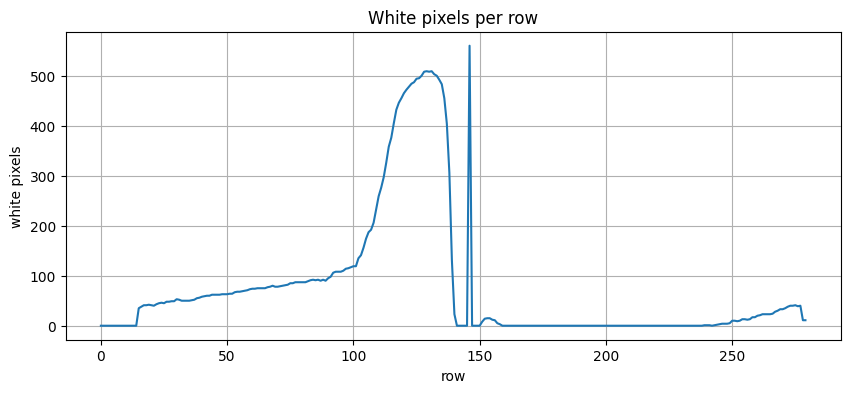

Detected baseline: 146


In [7]:
row_sums = mask.sum(axis=1)

plt.figure(figsize=(10,4))
plt.plot(row_sums)
plt.xlabel("row")
plt.ylabel("white pixels")
plt.title("White pixels per row")
plt.grid()
plt.show()

baseline_row = np.argmax(row_sums)
print("Detected baseline:", baseline_row)

## Initial velocity envelope extraction

In this section, the first surrogate velocity waveform is extracted from the Doppler spectrum.

The distance between the detected envelope and the baseline is treated as a proxy for blood flow velocity expressed in pixels.

This initial implementation is orientation-dependent and serves as an exploratory step before developing a direction-agnostic extraction method.

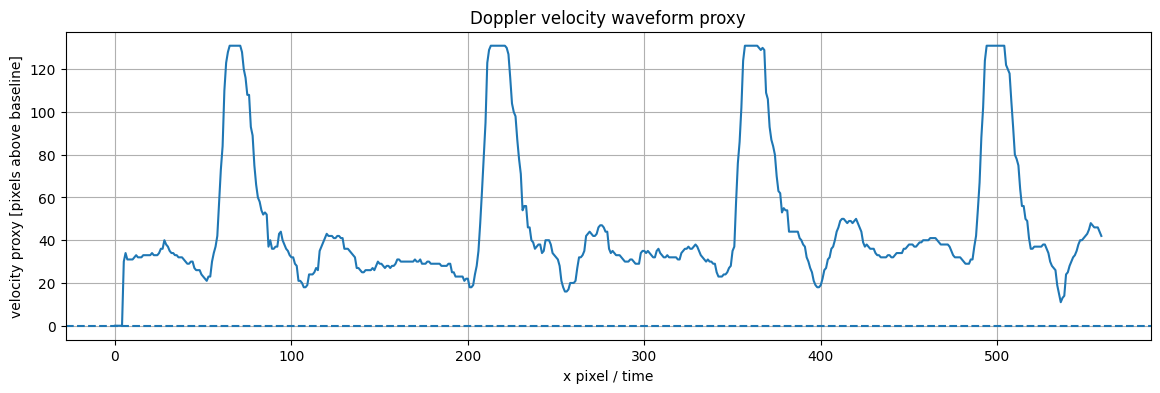

In [8]:
velocity_px = baseline_row - envelope

plt.figure(figsize=(14, 4))
plt.plot(velocity_px)
plt.axhline(0, linestyle="--")
plt.xlabel("x pixel / time")
plt.ylabel("velocity proxy [pixels above baseline]")
plt.title("Doppler velocity waveform proxy")
plt.grid()
plt.show()

## Initial PSV detection

In this section, local maxima of the extracted waveform are detected.

These peaks are treated as approximations of peak systolic velocity (PSV).

Detection parameters are manually selected and are not expected to generalize across different Doppler recordings.

The purpose of this step is to validate whether the extracted waveform contains physiologically meaningful pulsatile information.

Peaks: [ 68 217 360 499]


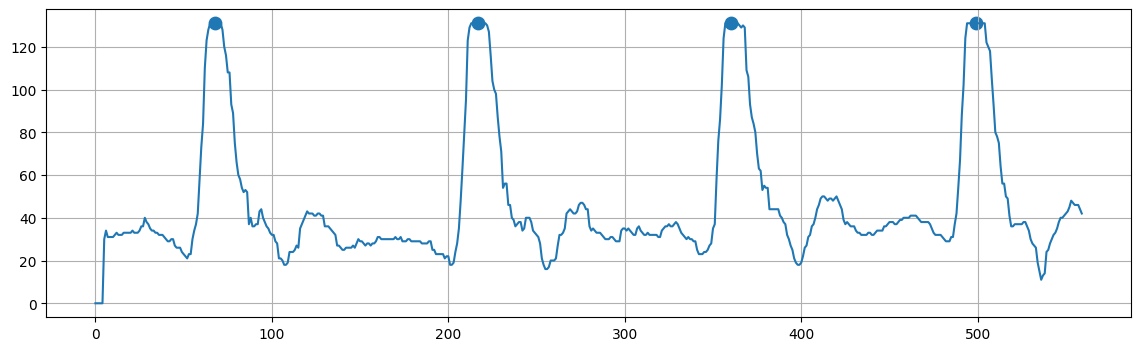

In [9]:
peaks, props = find_peaks(velocity_px, height=80, distance=100)
print("Peaks:", peaks)

plt.figure(figsize=(14,4))
plt.plot(velocity_px)
plt.scatter(peaks, velocity_px[peaks], s=80)
plt.grid()
plt.show()

## Waveform smoothing

In this section, the raw Doppler waveform is smoothed to reduce pixel-level noise.

A median filter is applied first, followed by Savitzky-Golay smoothing.

The objective is to preserve the overall waveform morphology while reducing high-frequency fluctuations introduced during image processing.

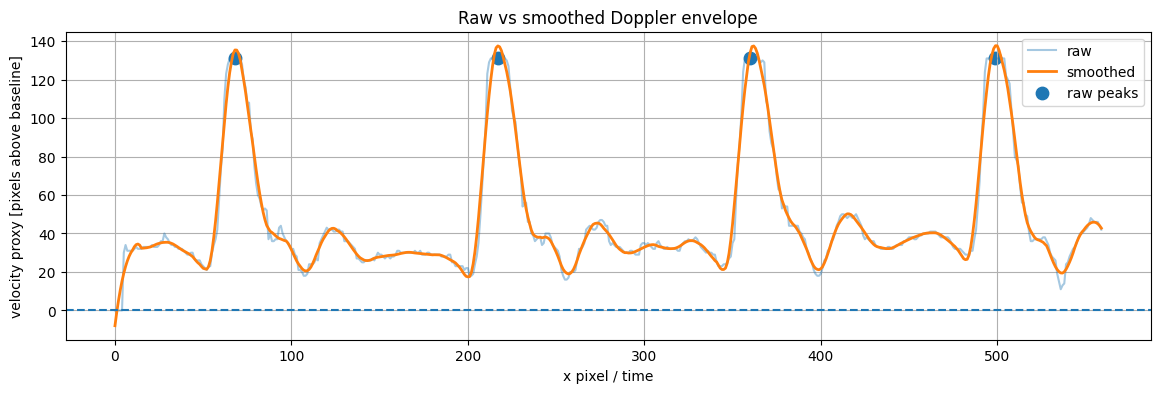

In [10]:
velocity_px_raw = velocity_px.copy()
velocity_px_med = medfilt(velocity_px_raw, kernel_size=5)
velocity_px_smooth = savgol_filter(velocity_px_med, window_length=21, polyorder=3)

plt.figure(figsize=(14, 4))
plt.plot(velocity_px_raw, alpha=0.4, label="raw")
plt.plot(velocity_px_smooth, linewidth=2, label="smoothed")
plt.scatter(peaks, velocity_px_raw[peaks], s=80, label="raw peaks")

plt.axhline(0, linestyle="--")
plt.xlabel("x pixel / time")
plt.ylabel("velocity proxy [pixels above baseline]")
plt.title("Raw vs smoothed Doppler envelope")
plt.legend()
plt.grid()
plt.show()

##  Initial PSV feature table

In this section, a simple table containing the location and amplitude of detected PSV peaks is generated.

This table is used as a diagnostic tool during development and is not intended to represent the final feature extraction output.

The extracted values are inspected to verify the consistency of peak detection across the waveform.

In [11]:
beat_rows = []
for i, peak in enumerate(peaks):
    beat_rows.append({
        "beat_id": i + 1,
        "peak_x": int(peak),
        "psv_px_raw": float(velocity_px_raw[peak]),
        "psv_px_smooth": float(velocity_px_smooth[peak]),
    })

beat_df = pd.DataFrame(beat_rows)
beat_df["cycle_length_px"] = beat_df["peak_x"].diff()
beat_df["psv_smooth_diff_pct"] = beat_df["psv_px_smooth"].pct_change() * 100

print(beat_df)

print("\nPSV smooth mean:", beat_df["psv_px_smooth"].mean())
print("PSV smooth std:", beat_df["psv_px_smooth"].std())
print("PSV smooth CV %:", beat_df["psv_px_smooth"].std() / beat_df["psv_px_smooth"].mean() * 100)

   beat_id  peak_x  psv_px_raw  psv_px_smooth  cycle_length_px  \
0        1      68       131.0     135.411246              NaN   
1        2     217       131.0     137.526643            149.0   
2        3     360       131.0     134.049036            143.0   
3        4     499       131.0     137.622099            139.0   

   psv_smooth_diff_pct  
0                  NaN  
1             1.562202  
2            -2.528679  
3             2.665490  

PSV smooth mean: 136.15225563909587
PSV smooth std: 1.7341673206336428
PSV smooth CV %: 1.2736970919016342


## Valley detection between PSV peaks

In this section, local minima located between consecutive PSV peaks are identified.

These valleys may correspond to the reduction in flow velocity following the systolic phase.

This step is used as an intermediate diagnostic stage before constructing the final beat-level morphology analysis implemented in `analyze_beats()`.

Valleys: [ 16 108 200 291 399 537]


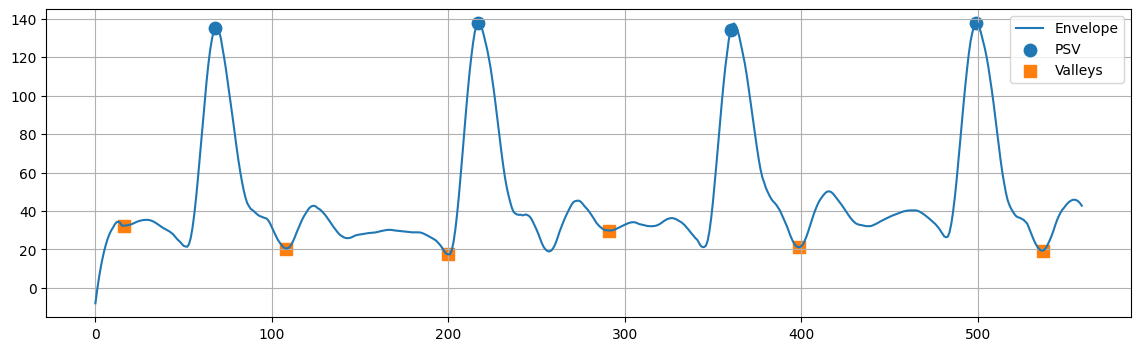

In [12]:
# minima velocity = peaks on inverted signal
valleys, _ = find_peaks(-velocity_px_smooth, distance=60)

print("Valleys:", valleys)
plt.figure(figsize=(14,4))
plt.plot(velocity_px_smooth, label="Envelope")
plt.scatter(peaks, velocity_px_smooth[peaks], s=80, label="PSV")
plt.scatter(valleys, velocity_px_smooth[valleys], s=80, marker="s", label="Valleys")
plt.legend()
plt.grid()
plt.show()

## Inspection of a single waveform segment

In this section, a short segment of the extracted Doppler waveform is selected for detailed inspection.

The selected segment is used to evaluate the local morphology of an individual Doppler pulse before developing automated beat-level analysis methods.

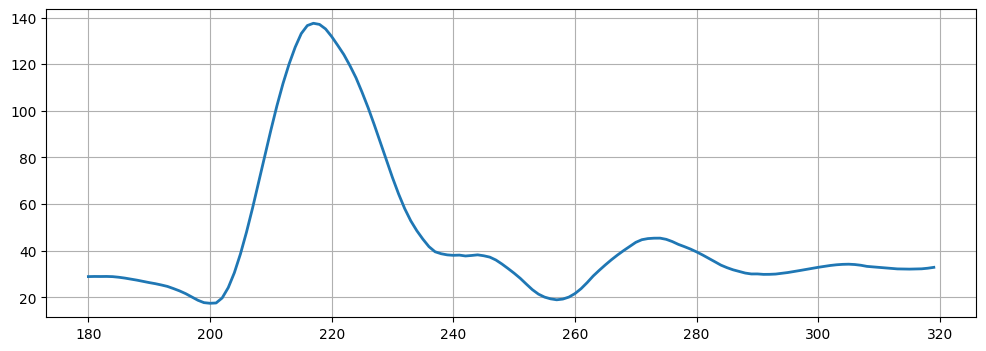

In [13]:
beat_start = 180
beat_end = 320
plt.figure(figsize=(12,4))
plt.plot(np.arange(beat_start, beat_end), velocity_px_smooth[beat_start:beat_end], linewidth=2)
plt.grid()
plt.show()

## Envelope validation on the Doppler mask

In this section, the extracted envelope is overlaid on the Doppler spectrum mask.

This visualization is used to verify whether the envelope correctly follows the outer boundary of the Doppler spectrum.

The purpose of this step is to identify extraction errors before proceeding to waveform analysis.

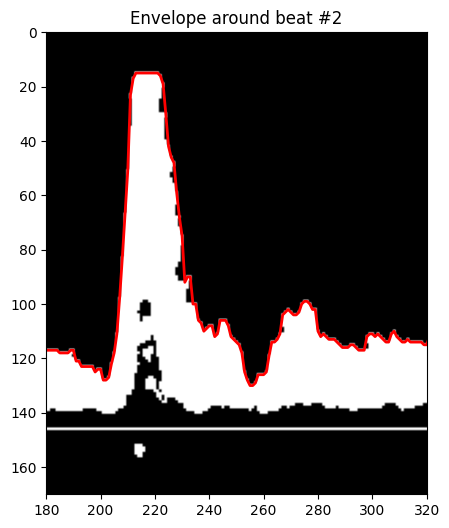

In [14]:
plt.figure(figsize=(12,6))
plt.imshow(mask, cmap="gray")
plt.plot(np.arange(len(envelope)), envelope, color="red", linewidth=2)
plt.xlim(180, 320)
plt.ylim(170, 0)
plt.title("Envelope around beat #2")
plt.show()

## Local analysis of peaks, valleys, and secondary waves

In this section, a manually selected waveform segment is examined in detail.

Local peaks, valleys, and secondary waveform components are inspected to better understand the morphology of the Doppler signal.

The observations from this exploratory analysis are later incorporated into the design of the automated beat analysis pipeline.

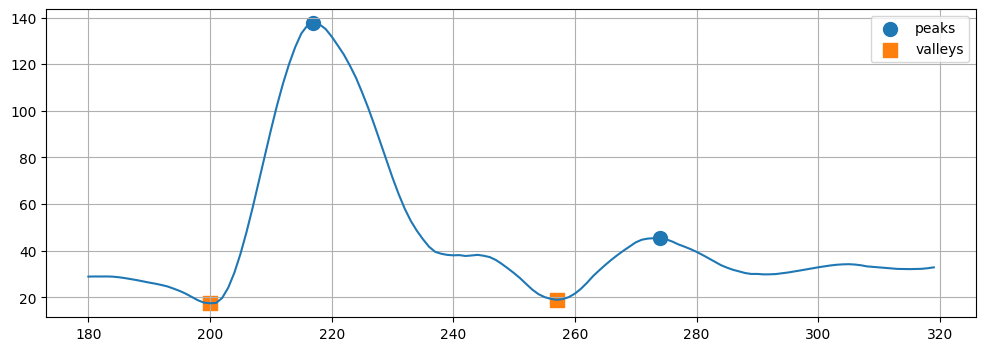

In [15]:
segment = velocity_px_smooth[180:320]
# local peak detection
local_peaks, _ = find_peaks(segment, prominence=5)
# local valleys
local_valleys, _ = find_peaks(-segment, prominence=5)
plt.figure(figsize=(12,4))
plt.plot(np.arange(180,320), segment)

plt.scatter(180 + local_peaks, segment[local_peaks], s=100, label="peaks")
plt.scatter(180 + local_valleys, segment[local_valleys], s=100, marker="s", label="valleys")
plt.legend()
plt.grid()
plt.show()

##  Alternative waveform representation: intensity-weighted mean

In this section, an alternative waveform extraction approach is explored.

Instead of using the Doppler envelope, the signal is represented by the intensity-weighted mean position of Doppler pixels.

This approach may better describe the spectral energy distribution; however, it represents a different physiological quantity and should not be mixed with envelope-derived measurements without clear separation.

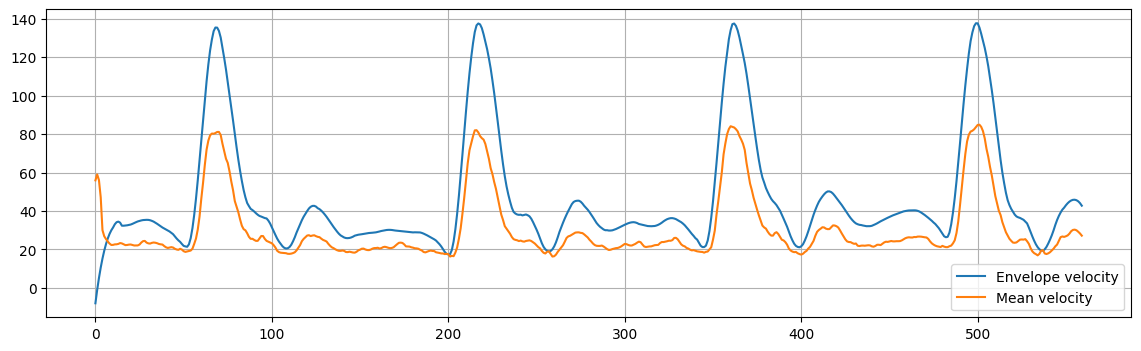

In [16]:
gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
baseline = 146
mean_velocity = np.full(gray.shape[1], np.nan)

for x in range(gray.shape[1]):
    column = gray[:baseline, x]
    weights = column.astype(float)

    if weights.sum() > 0:
        y = np.arange(len(column))
        centroid = np.sum(y * weights) / np.sum(weights)
        mean_velocity[x] = baseline - centroid

plt.figure(figsize=(14,4))

plt.plot(velocity_px_smooth, label="Envelope velocity")

plt.plot(mean_velocity, label="Mean velocity")
plt.legend()
plt.grid()
plt.show()

##  Whole-recording stability assessment

In this section, baseline stability and Doppler signal consistency are evaluated across multiple video frames.

The objective is to determine whether a single ROI configuration and baseline estimate can be reliably used throughout the entire recording.

This analysis provides preliminary evidence for the feasibility of extending the image-processing pipeline from a single frame to a complete Doppler video.

Frames: 183
Baseline mean: 146.0
Baseline std : 0.0
Baseline min : 146
Baseline max : 146


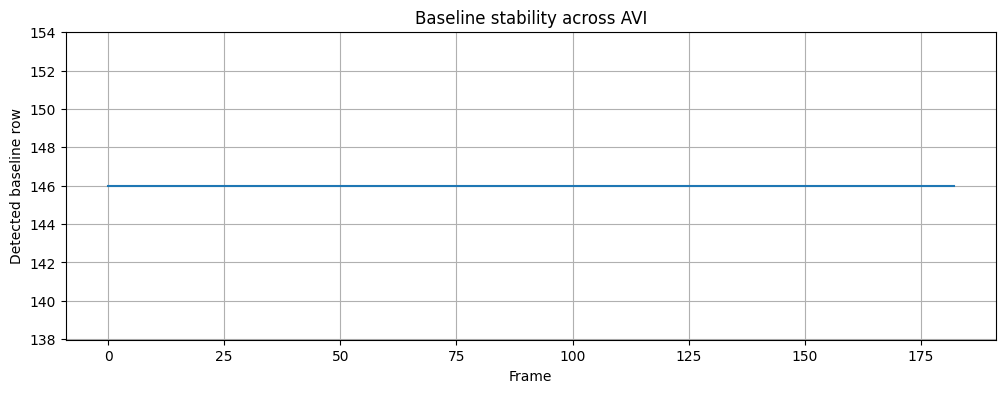

In [17]:
x_min, x_max = 80, 640
y_min, y_max = 230, 510

cap = cv2.VideoCapture(video_path_a)

baseline_values = []
frame_ids = []

frame_idx = 0

while True:

    ok, frame = cap.read()

    if not ok:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    roi = frame_rgb[y_min:y_max, x_min:x_max]
    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    mask = gray > 80
    row_sums = mask.sum(axis=1)
    baseline_row = np.argmax(row_sums)
    baseline_values.append(baseline_row)
    frame_ids.append(frame_idx)
    frame_idx += 1

cap.release()

baseline_values = np.asarray(baseline_values)

print("Frames:", len(baseline_values))
print("Baseline mean:", baseline_values.mean())
print("Baseline std :", baseline_values.std())
print("Baseline min :", baseline_values.min())
print("Baseline max :", baseline_values.max())

plt.figure(figsize=(12,4))
plt.plot(frame_ids, baseline_values)
plt.xlabel("Frame")
plt.ylabel("Detected baseline row")
plt.title("Baseline stability across AVI")
plt.grid()
plt.show()

Frame PSV mean: 131.0
Frame PSV std : 0.0
Frame PSV min : 131.0
Frame PSV max : 131.0


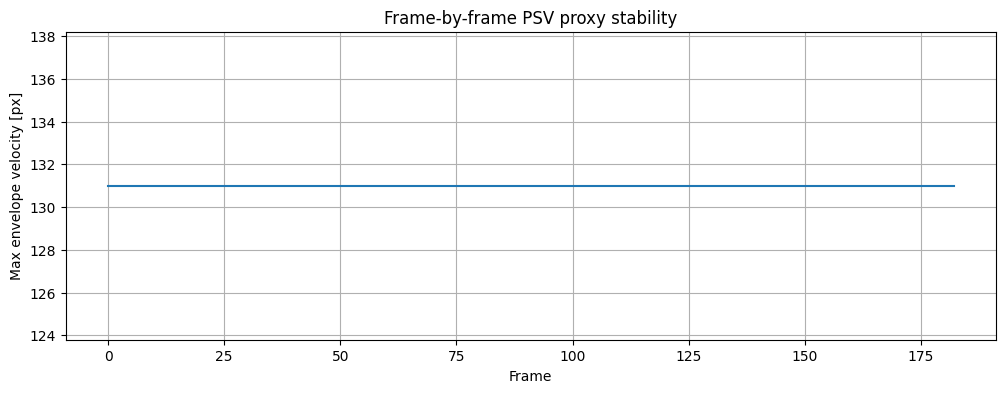

In [18]:
frame_psv = []
frame_ids = []

cap = cv2.VideoCapture(video_path_a)
frame_idx = 0

while True:
    ok, frame = cap.read()
    if not ok:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    roi = frame_rgb[y_min:y_max, x_min:x_max]
    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    mask = gray > 80

    envelope = np.full(mask.shape[1], np.nan)

    for x in range(mask.shape[1]):
        ys = np.where(mask[:146, x])[0]
        if len(ys):
            envelope[x] = ys.min()

    velocity_px = 146 - envelope
    frame_psv.append(np.nanmax(velocity_px))
    frame_ids.append(frame_idx)
    frame_idx += 1

cap.release()

frame_psv = np.asarray(frame_psv)

print("Frame PSV mean:", np.nanmean(frame_psv))
print("Frame PSV std :", np.nanstd(frame_psv))
print("Frame PSV min :", np.nanmin(frame_psv))
print("Frame PSV max :", np.nanmax(frame_psv))

plt.figure(figsize=(12,4))
plt.plot(frame_ids, frame_psv)
plt.xlabel("Frame")
plt.ylabel("Max envelope velocity [px]")
plt.title("Frame-by-frame PSV proxy stability")
plt.grid()
plt.show()

## Doppler envelope extraction

In this section, the core Doppler envelope extraction algorithm is implemented.

For each image column, the outermost Doppler spectrum boundary is identified relative to the detected baseline.

Three operating modes are supported:

- `above` – the Doppler spectrum is located above the baseline,
- `below` – the Doppler spectrum is located below the baseline,
- `auto` – the spectrum orientation is determined automatically from the signal distribution around the baseline.

Short isolated mask segments are removed as potential image noise before envelope extraction.

The objective of this stage is to generate a robust Doppler envelope that is independent of spectrum orientation.

In [19]:
def extract_envelope_directional(mask, baseline, direction="auto", min_segment_length=5):
    """
    Extract the Doppler spectrum envelope from a binary mask.

    The envelope is detected relative to the Doppler baseline and can
    operate on spectra located either above or below the baseline.

    Returns the envelope position, velocity proxy, and the selected
    spectrum orientation.
    """

    if direction not in ["auto", "above", "below"]:
        raise ValueError("direction must be 'auto', 'above', or 'below'")
    if baseline <= 0 or baseline >= mask.shape[0] - 1:
        raise ValueError("Baseline is outside valid ROI range.")
    if min_segment_length < 1:
        raise ValueError("min_segment_length must be >= 1.")

    above_area = int(mask[:baseline, :].sum())
    below_area = int(mask[baseline + 1:, :].sum())

    if direction == "auto":
        selected_direction = "above" if above_area >= below_area else "below"
    else:
        selected_direction = direction

    envelope = np.full(mask.shape[1], np.nan)

    for x in range(mask.shape[1]):

        if selected_direction == "above":
            ys = np.where(mask[:baseline, x])[0]
        else:
            ys_local = np.where(mask[baseline + 1:, x])[0]
            ys = baseline + 1 + ys_local

        if len(ys) == 0:
            continue

        breaks = np.where(np.diff(ys) > 1)[0] + 1
        segments = np.split(ys, breaks)
        valid_segments = [segment for segment in segments if len(segment) >= min_segment_length]

        if len(valid_segments) == 0:
            continue
        if selected_direction == "above":
            envelope[x] = min(segment.min() for segment in valid_segments)
        else:
            envelope[x] = max(segment.max() for segment in valid_segments)

    if selected_direction == "above":
        velocity = baseline - envelope
    else:
        velocity = envelope - baseline

    return envelope, velocity, selected_direction

## Doppler waveform extraction

In this section, the Doppler spectrum image is converted into a one-dimensional waveform representing blood flow velocity.

The processing pipeline includes:

1. ROI extraction,
2. grayscale conversion,
3. Doppler mask generation,
4. baseline detection,
5. envelope extraction,
6. interpolation of missing values,
7. median filtering,
8. Savitzky-Golay smoothing,
9. PSV peak detection.

The resulting waveform and all intermediate processing outputs are stored for diagnostic visualization and downstream morphology analysis.

In [20]:
def extract_doppler_waveform(
    frame_rgb,
    x_min=80,
    x_max=640,
    y_min=230,
    y_max=510,
    threshold=80,
    direction="auto",
    min_segment_length=5,
    trim_left=10,
    trim_right=10,
    median_kernel_size=5,
    savgol_window_length=21,
    savgol_polyorder=3,
    peak_height=80,
    peak_distance=100,
):
    """
    Extract and smooth a Doppler waveform from a single RGB video frame.

    The function detects the Doppler baseline, extracts the spectrum envelope,
    trims edge artifacts, smooths the waveform, and detects PSV peaks.

    Returns a dictionary with intermediate outputs, waveform arrays, and
    local/global PSV peak positions.
    """
    roi = frame_rgb[y_min:y_max, x_min:x_max]
    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold
    row_sums = mask.sum(axis=1)
    baseline = int(np.argmax(row_sums))

    envelope, velocity_raw, selected_direction = extract_envelope_directional(
        mask=mask,
        baseline=baseline,
        direction=direction,
        min_segment_length=min_segment_length,
    )

    if trim_left < 0 or trim_right < 0:
        raise ValueError("trim_left and trim_right must be non-negative.")

    if trim_left + trim_right >= len(envelope):
        raise ValueError("trim_left + trim_right is too large for signal length.")

    if trim_right == 0:
        keep_slice = slice(trim_left, None)
    else:
        keep_slice = slice(trim_left, -trim_right)

    envelope = envelope[keep_slice]
    velocity_raw = velocity_raw[keep_slice]
    x_offset = trim_left
    valid = np.where(~np.isnan(envelope))[0]

    if len(valid) == 0:
        raise ValueError("No valid envelope points found. Check ROI, threshold, Doppler direction, min_segment_length, or trim settings.")

    envelope_interp = np.interp(
        np.arange(len(envelope)), valid, envelope[valid])

    velocity_raw = np.interp(np.arange(len(velocity_raw)), valid, velocity_raw[valid])

    if median_kernel_size % 2 == 0:
        median_kernel_size += 1

    velocity_med = medfilt(velocity_raw, kernel_size=median_kernel_size)

    if savgol_window_length % 2 == 0:
        savgol_window_length += 1

    if savgol_window_length >= len(velocity_med):
        savgol_window_length = len(velocity_med) - 1

        if savgol_window_length % 2 == 0:
            savgol_window_length -= 1

    if savgol_window_length <= savgol_polyorder:
        raise ValueError("savgol_window_length must be greater than savgol_polyorder.")

    velocity_smooth = savgol_filter(velocity_med, window_length=savgol_window_length, polyorder=savgol_polyorder)

    peaks_local, peak_props = find_peaks(velocity_smooth, height=peak_height, distance=peak_distance)

    peaks_global = peaks_local + x_offset

    return {
        "roi": roi,
        "gray": gray,
        "mask": mask,
        "baseline": baseline,
        "direction": selected_direction,
        "min_segment_length": min_segment_length,
        "trim_left": trim_left,
        "trim_right": trim_right,
        "x_offset": x_offset,
        "envelope": envelope_interp,
        "velocity_raw": velocity_raw,
        "velocity_med": velocity_med,
        "velocity_smooth": velocity_smooth,
        "peaks_local": peaks_local,
        "peaks_global": peaks_global,
        "peaks": peaks_local,
        "peak_props": peak_props,
    }

## Doppler extraction quality assessment

In this section, the Doppler extraction pipeline is visually validated.

The following outputs are displayed:

- the original ROI,
- the Doppler mask,
- the extracted envelope,
- the detected baseline,
- the final waveform together with detected PSV peaks.

The purpose of this visualization is to verify that the extracted waveform accurately represents the Doppler spectrum before beat-level morphology analysis is performed.

In [21]:
def plot_doppler_extraction_result(result, title="Doppler extraction result"):
    """
    Visualize the main stages of Doppler waveform extraction.

    Displays the ROI, extracted envelope, detected baseline,
    and the final Doppler waveform with PSV peaks.
    """

    roi = result["roi"]
    mask = result["mask"]
    baseline = result["baseline"]
    envelope = result["envelope"]
    velocity_smooth = result["velocity_smooth"]
    peaks = result["peaks"]
    direction = result["direction"]

    trim_left = result.get("trim_left", 0)
    x_offset = result.get("x_offset", 0)

    x_envelope = np.arange(len(envelope)) + x_offset
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # ROI
    axes[0].imshow(roi)
    axes[0].set_title(f"{title} | ROI | direction={direction}")
    axes[0].axis("off")

    # MASK + ENVELOPE
    axes[1].imshow(mask, cmap="gray")
    axes[1].plot(x_envelope, envelope, linewidth=2, label="envelope")
    axes[1].axhline(baseline, linestyle="--", linewidth=2, label="baseline")
    axes[1].set_title("Mask with extracted envelope and baseline")
    axes[1].set_ylabel("ROI y [px]")
    axes[1].legend()

    # VELOCITY
    x_velocity = np.arange(len(velocity_smooth))

    axes[2].plot(x_velocity, velocity_smooth, linewidth=2, label="velocity smooth")
    axes[2].scatter(peaks, velocity_smooth[peaks], s=60, label="detected PSV peaks")
    axes[2].set_title(f"Extracted Doppler velocity proxy (trim_left={trim_left})")
    axes[2].set_xlabel("ROI x [px]")
    axes[2].set_ylabel("Velocity proxy [px]" )
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

## Single-frame extraction validation

In this section, the Doppler waveform extraction pipeline is evaluated on a single video frame.

The objective is to verify that:

- the baseline is detected correctly,
- the Doppler spectrum orientation is identified correctly,
- the waveform can be reconstructed from the image,
- PSV peaks can be detected reliably.

The extracted waveform is visualized together with detected PSV peaks to assess the overall quality of the extraction process.

Baseline: 146
Direction: above
Peaks: [ 58 196 341 479]


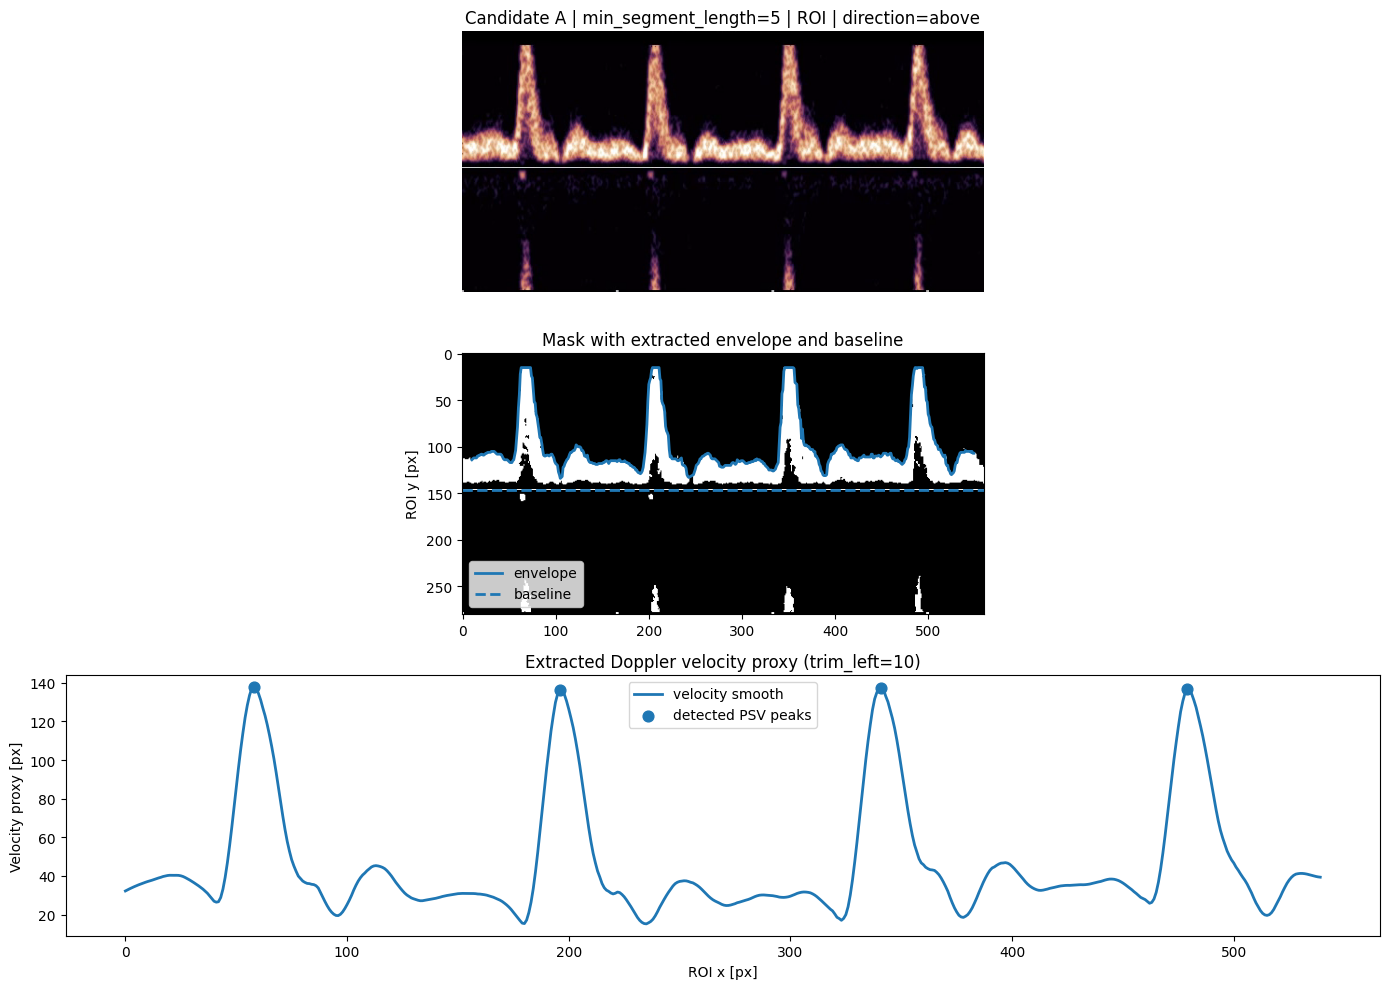

In [22]:
result = extract_doppler_waveform(
    frame_rgb=frame_rgb,
    direction="auto",
    min_segment_length=5,
    trim_left=10,
    trim_right=10,
)

print("Baseline:", result["baseline"])
print("Direction:", result["direction"])
print("Peaks:", result["peaks"])

plot_doppler_extraction_result(result, title="Candidate A | min_segment_length=5")

Baseline: 146
Direction: below
Peaks: [ 55 178 302 423]


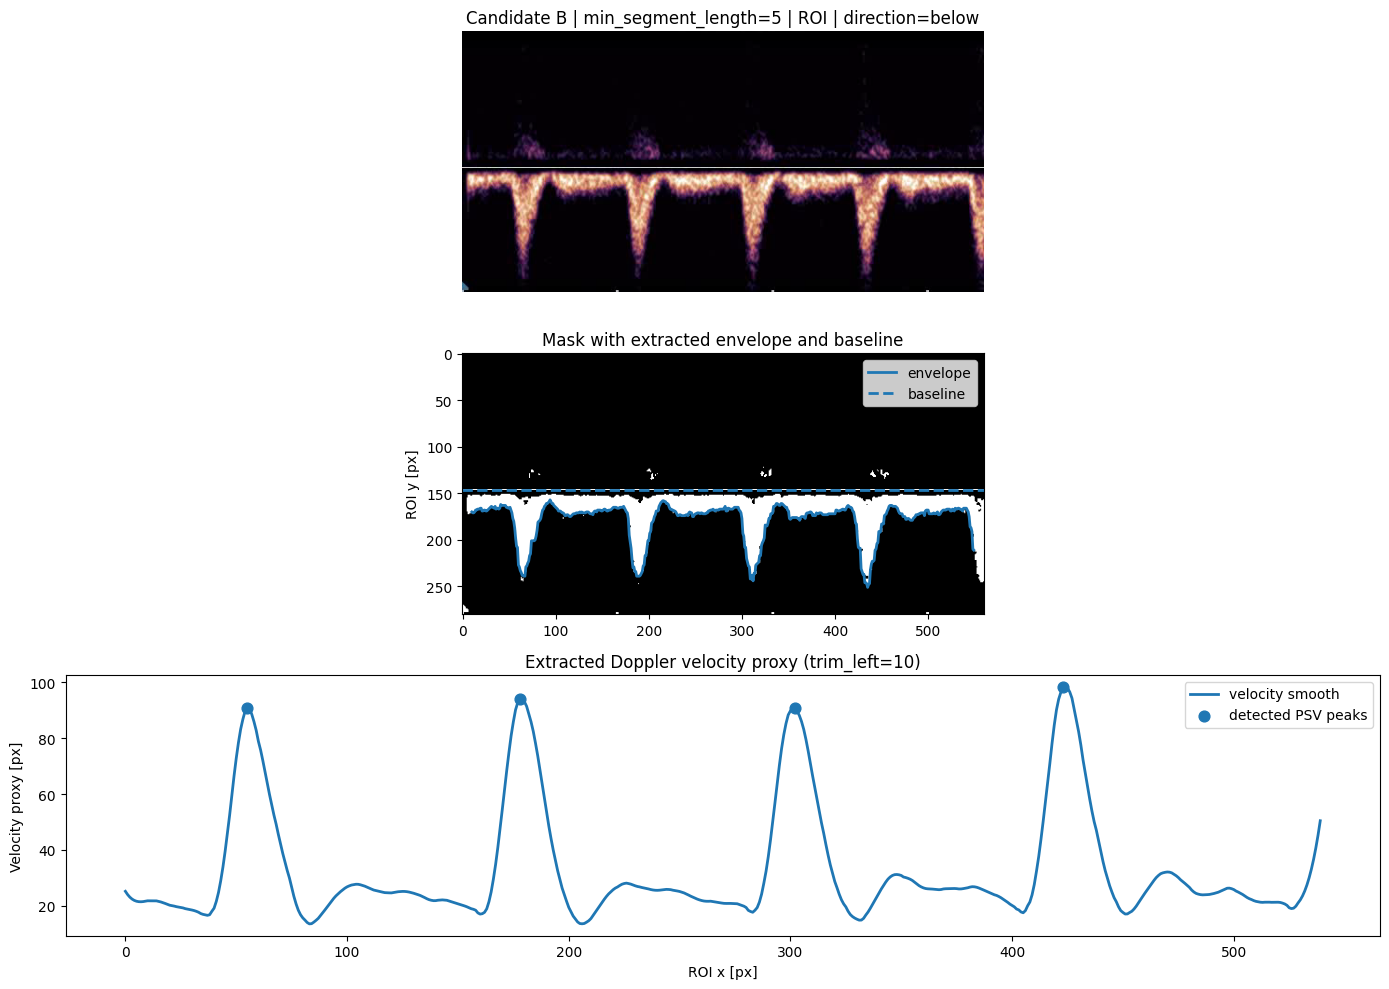

In [23]:
result_b = extract_doppler_waveform(
    frame_rgb=frame_rgb_b,
    direction="auto",
    min_segment_length=5,
    trim_left=10,
    trim_right=10,
)

print("Baseline:", result_b["baseline"])
print("Direction:", result_b["direction"])
print("Peaks:", result_b["peaks"])

plot_doppler_extraction_result(result_b,  title="Candidate B | min_segment_length=5")

In [24]:
print("Candidate A")
print("peaks_local:", result["peaks_local"])
print("peaks_global:", result["peaks_global"])

print("Candidate B")
print("peaks_local:", result_b["peaks_local"])
print("peaks_global:", result_b["peaks_global"])

Candidate A
peaks_local: [ 58 196 341 479]
peaks_global: [ 68 206 351 489]
Candidate B
peaks_local: [ 55 178 302 423]
peaks_global: [ 65 188 312 433]


## Validation on recordings with different spectrum orientation

In this section, the extraction algorithm is validated on two Doppler recordings with different spectrum orientations.

The objective is to verify that the orientation-agnostic extraction approach correctly handles both:

- spectra located above the baseline,
- spectra located below the baseline.

Local and global peak positions are inspected to confirm that waveform reconstruction and PSV detection remain consistent across recordings.

In [25]:
cap = cv2.VideoCapture(video_path_a)
cap.set(cv2.CAP_PROP_POS_FRAMES, 92)
ok, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
result = extract_doppler_waveform(frame_rgb=frame_rgb, direction="auto")

print("Baseline:", result["baseline"])
print("Direction:", result["direction"])
print("Peaks:", result["peaks"])

Baseline: 146
Direction: above
Peaks: [ 59 207 352 489]


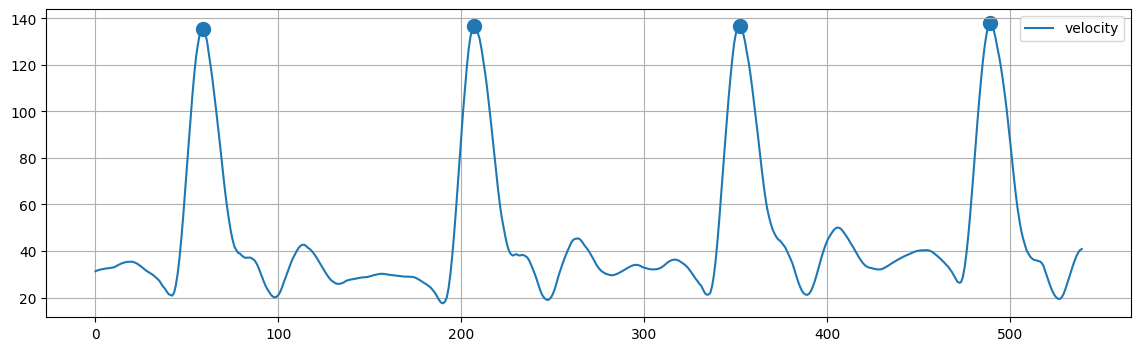

In [26]:
plt.figure(figsize=(14,4))
plt.plot(result["velocity_smooth"], label="velocity")
plt.scatter(result["peaks"], result["velocity_smooth"][result["peaks"]], s=100)
plt.grid()
plt.legend()
plt.show()

## Beat-level morphology analysis

In this section, individual Doppler cardiac cycles are identified and analyzed between consecutive PSV peaks.

For each cycle, the following morphology features are extracted:

- peak systolic velocity (PSV),
- the first post-systolic valley,
- a secondary peak following the valley,
- cycle length,
- a proxy resistive index (RI),
- basic timing features.

In addition, a simple quality-control procedure is applied to identify incomplete or morphologically inconsistent cycles.

Cycles that fail quality-control checks are marked as incomplete and can be excluded from downstream analyses.

In [27]:
def analyze_beats(
    result,
    min_valley_distance_from_psv=10,
    secondary_peak_search_start_after_valley=5,
    secondary_peak_search_end_after_psv=70,
    min_time_to_valley_px=15,
    max_time_to_valley_fraction=0.65,
    require_secondary_peak=True,
):
    """
    Extract beat-level morphology features from a Doppler waveform.

    The function identifies cycles between consecutive PSV peaks, detects
    the first post-systolic valley and secondary peak, and applies simple
    morphology-based beat quality checks.

    Returns a DataFrame with beat features and quality flags.
    """
    velocity = result["velocity_smooth"]
    peaks_local = result["peaks_local"]
    peaks_global = result["peaks_global"]
    x_offset = result["x_offset"]

    rows = []

    for i in range(len(peaks_local) - 1):
        psv_local = int(peaks_local[i])
        next_psv_local = int(peaks_local[i + 1])

        psv_global = int(peaks_global[i])
        next_psv_global = int(peaks_global[i + 1])

        beat_start = psv_local
        beat_end = next_psv_local

        if beat_end <= beat_start:
            continue

        cycle_length_px = int(next_psv_local - psv_local)
        psv_value = float(velocity[psv_local])

        valley_search_start = beat_start + min_valley_distance_from_psv
        valley_search_end = beat_end

        if valley_search_start >= valley_search_end:
            continue

        valley_region = velocity[valley_search_start:valley_search_end]

        if len(valley_region) == 0:
            continue

        first_valley_local = int(valley_search_start + np.argmin(valley_region))
        first_valley_global = int(first_valley_local + x_offset)
        first_valley_value = float(velocity[first_valley_local])
        time_to_valley_px = int(first_valley_local - psv_local)
        secondary_start = (first_valley_local + secondary_peak_search_start_after_valley)
        secondary_end = min(beat_start + secondary_peak_search_end_after_psv, beat_end)

        if secondary_start < secondary_end:

            secondary_region = velocity[secondary_start:secondary_end]

            if len(secondary_region) > 0:
                secondary_peak_local = int(secondary_start + np.argmax(secondary_region))
                secondary_peak_global = int(secondary_peak_local + x_offset)
                secondary_peak_value = float(velocity[secondary_peak_local])
            else:
                secondary_peak_local = np.nan
                secondary_peak_global = np.nan
                secondary_peak_value = np.nan

        else:
            secondary_peak_local = np.nan
            secondary_peak_global = np.nan
            secondary_peak_value = np.nan

        if not np.isnan(secondary_peak_local):
            time_to_secondary_peak_px = int(secondary_peak_local - psv_local)
        else:
            time_to_secondary_peak_px = np.nan

        edv_proxy = first_valley_value
        ri_proxy = ((psv_value - edv_proxy) / psv_value if psv_value > 0 else np.nan)
        valley_to_psv_ratio = (first_valley_value / psv_value if psv_value > 0 else np.nan)
        secondary_to_psv_ratio = (secondary_peak_value / psv_value if psv_value > 0 and not np.isnan(secondary_peak_value) else np.nan)

        quality_reasons = []

        if time_to_valley_px < min_time_to_valley_px:
            quality_reasons.append("valley_too_early")
        if time_to_valley_px > cycle_length_px * max_time_to_valley_fraction:
            quality_reasons.append("valley_too_late")
        if require_secondary_peak and np.isnan(secondary_peak_local):
            quality_reasons.append("missing_secondary_peak")

        is_complete_beat = len(quality_reasons) == 0
        beat_quality_reason = ("ok" if is_complete_beat else ";".join(quality_reasons))

        rows.append(
            {
                "beat_id": i + 1,

                "is_complete_beat": is_complete_beat,
                "beat_quality_reason": beat_quality_reason,

                "psv_local": psv_local,
                "psv_global": psv_global,
                "psv_value_px": psv_value,

                "next_psv_local": next_psv_local,
                "next_psv_global": next_psv_global,

                "first_valley_local": first_valley_local,
                "first_valley_global": first_valley_global,
                "first_valley_value_px": first_valley_value,

                "secondary_peak_local": secondary_peak_local,
                "secondary_peak_global": secondary_peak_global,
                "secondary_peak_value_px": secondary_peak_value,

                "cycle_length_px": cycle_length_px,
                "time_to_valley_px": time_to_valley_px,
                "time_to_secondary_peak_px": time_to_secondary_peak_px,

                "valley_to_psv_ratio": valley_to_psv_ratio,
                "secondary_to_psv_ratio": secondary_to_psv_ratio,
                "ri_proxy": ri_proxy,
            }
        )

    beat_df = pd.DataFrame(rows)

    return beat_df

## Recording-level feature aggregation

In this section, beat-level morphology features are aggregated into recording-level summary statistics.

Only cycles that pass the quality-control stage are included in the calculations.

The extracted summary features include:

- mean PSV,
- mean EDV proxy,
- mean RI proxy,
- mean cycle duration,
- mean time to valley,
- mean time to secondary peak,
- proportion of complete cycles.

The resulting feature set provides a compact representation of the Doppler recording and can be used for future comparisons with audio-derived features.

In [28]:
def summarize_complete_beats(beat_df):
    """
    Aggregate complete Doppler beats into recording-level features.

    Computes summary statistics from beats that passed morphology
    quality control and returns a one-row summary table.
    """

    if len(beat_df) == 0:
        raise ValueError("beat_df is empty.")

    complete_beats = beat_df[beat_df["is_complete_beat"]].copy()
    n_total = len(beat_df)
    n_complete = len(complete_beats)

    if n_complete == 0:
        return pd.DataFrame([{"n_total_beats": n_total, "n_complete_beats": 0, "complete_fraction": 0.0,}])
        
    summary = {
        "n_total_beats": n_total,
        "n_complete_beats" : n_complete,
        "complete_fraction" : n_complete / n_total,
        "mean_psv_px" : complete_beats["psv_value_px"].mean(),
        "std_psv_px" : complete_beats["psv_value_px"].std(),
        "mean_edv_proxy_px": complete_beats["first_valley_value_px"].mean(),
        "mean_ri_proxy": complete_beats["ri_proxy"].mean(),
        "std_ri_proxy": complete_beats["ri_proxy"].std(),
        "mean_cycle_length_px": complete_beats["cycle_length_px"].mean(),
        "mean_time_to_valley_px": complete_beats["time_to_valley_px"].mean(),
        "mean_time_to_secondary_peak_px": complete_beats["time_to_secondary_peak_px"].mean(),
        "mean_secondary_to_psv_ratio": complete_beats["secondary_to_psv_ratio"].mean(),
    }

    return pd.DataFrame([summary])

## Beat morphology visualization

In this section, detected morphology landmarks are visualized on the extracted Doppler waveform.

The visualization displays:

- PSV peaks,
- post-systolic valleys,
- secondary peaks,
- beat numbering.

The objective is to verify that the automated beat analysis algorithm identifies physiologically meaningful waveform features before quantitative measurements are calculated.

In [29]:
def plot_beat_analysis(result, beat_df, title="Beat morphology analysis"):
    """
    Visualize PSV, first valley and secondary peak
    on extracted Doppler waveform.
    """
    velocity = result["velocity_smooth"]
    plt.figure(figsize=(14, 6))
    plt.plot(velocity, linewidth=2, label="velocity_smooth")

    for _, row in beat_df.iterrows():
        # PSV
        plt.scatter(row["psv_local"], row["psv_value_px"], s=80, marker="o", label=None)
        plt.text(row["psv_local"], row["psv_value_px"] + 3, f'PSV {int(row["beat_id"])}', fontsize=8)

        # Valley
        plt.scatter(row["first_valley_local"], row["first_valley_value_px"], s=80, marker="v", label=None)

        # Secondary peak
        if not pd.isna(row["secondary_peak_local"]):
            plt.scatter( row["secondary_peak_local"], row["secondary_peak_value_px"], s=80, marker="s", label=None)

    plt.title(title)
    plt.xlabel("Signal position [px]")
    plt.ylabel("Velocity proxy [px]")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Beat morphology validation

In this section, beat-level morphology analysis is evaluated on Doppler recordings with different spectrum orientations.

Detected PSV peaks, valleys, and secondary peaks are inspected visually to verify the robustness of the morphology extraction pipeline.

In [30]:
beat_df = analyze_beats(result)
beat_df

,beat_id,is_complete_beat,beat_quality_reason,psv_local,psv_global,psv_value_px,next_psv_local,next_psv_global,first_valley_local,first_valley_global,first_valley_value_px,secondary_peak_local,secondary_peak_global,secondary_peak_value_px,cycle_length_px,time_to_valley_px,time_to_secondary_peak_px,valley_to_psv_ratio,secondary_to_psv_ratio,ri_proxy
0,1,False,valley_too_late;missing_secondary_peak,59,69,135.421706,207,217,190,200,17.554756,NaN,NaN,NaN,148,131,NaN,0.129630,NaN,0.870370
1,2,True,ok,207,217,136.578947,352,362,247,257,18.933312,264.0,274.0,45.377901,145,40,57.0,0.138625,0.332247,0.861375
2,3,True,ok,352,362,136.726708,489,499,389,399,21.145472,406.0,416.0,50.064727,137,37,54.0,0.154655,0.366166,0.845345


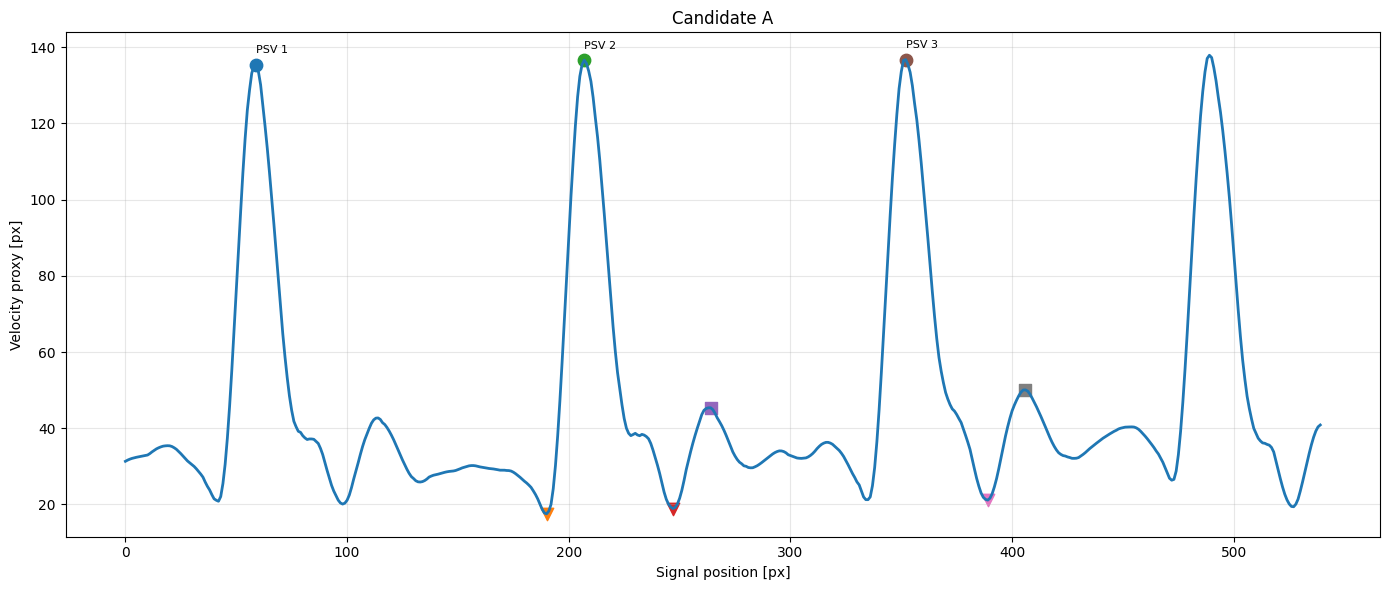

In [31]:
plot_beat_analysis(result, beat_df, title="Candidate A")

In [32]:
beat_df_b = analyze_beats(result_b)
beat_df_b

,beat_id,is_complete_beat,beat_quality_reason,psv_local,psv_global,psv_value_px,next_psv_local,next_psv_global,first_valley_local,first_valley_global,first_valley_value_px,secondary_peak_local,secondary_peak_global,secondary_peak_value_px,cycle_length_px,time_to_valley_px,time_to_secondary_peak_px,valley_to_psv_ratio,secondary_to_psv_ratio,ri_proxy
0,1,True,ok,55,65,90.941811,178,188,83,93,13.548872,104,114,27.722131,123,28,49,0.148984,0.304834,0.851016
1,2,True,ok,178,188,94.003923,302,312,206,216,13.576659,226,236,28.125204,124,28,48,0.144427,0.299192,0.855573
2,3,True,ok,302,312,90.788493,423,433,331,341,14.886564,348,358,31.212815,121,29,46,0.163970,0.343797,0.836030


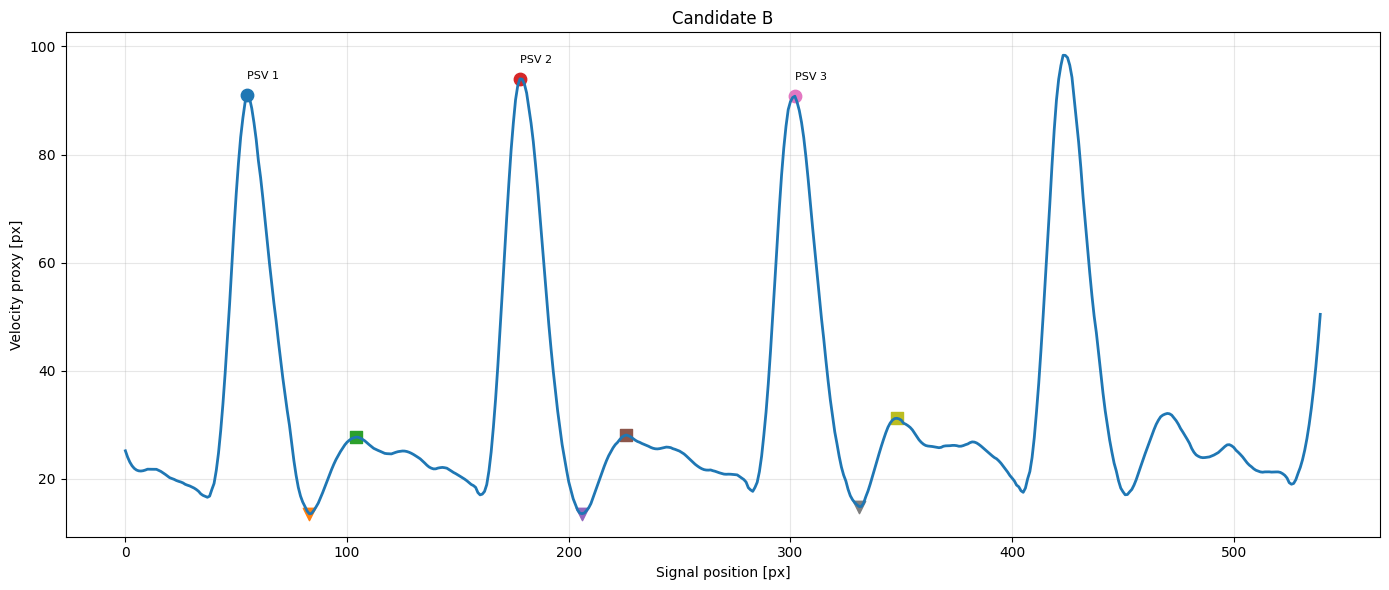

In [33]:
plot_beat_analysis(result_b, beat_df_b, title="Candidate B")

## Recording-level validation on candidate recordings

In this section, recording-level summaries are calculated for the candidate Doppler recordings.

Only complete beats are included in the aggregated measurements.

The resulting tables are used to compare whether the same image-processing pipeline produces consistent morphology features across recordings.

In [34]:
summary_a = summarize_complete_beats(beat_df)
summary_a

,n_total_beats,n_complete_beats,complete_fraction,mean_psv_px,std_psv_px,mean_edv_proxy_px,mean_ri_proxy,std_ri_proxy,mean_cycle_length_px,mean_time_to_valley_px,mean_time_to_secondary_peak_px,mean_secondary_to_psv_ratio
0,3,2,0.666667,136.652828,0.104483,20.039392,0.85336,0.011335,141.0,38.5,55.5,0.349207


In [35]:
summary_b = summarize_complete_beats(beat_df_b)
summary_b

,n_total_beats,n_complete_beats,complete_fraction,mean_psv_px,std_psv_px,mean_edv_proxy_px,mean_ri_proxy,std_ri_proxy,mean_cycle_length_px,mean_time_to_valley_px,mean_time_to_secondary_peak_px,mean_secondary_to_psv_ratio
0,3,3,1.0,91.911409,1.813791,14.004032,0.84754,0.010225,122.666667,28.333333,47.666667,0.315941


## Single-frame Doppler processing pipeline

In this section, the full image-based Doppler processing pipeline is wrapped into a single function.

A single RGB frame is processed through the following steps:

- Doppler waveform extraction,
- PSV detection,
- beat-level morphology analysis,
- beat quality control,
- recording-level feature aggregation.

The function returns three objects:

- `result` - intermediate extraction outputs used for diagnostics,
- `beat_df` - beat-level morphology features,
- `summary_df` - aggregated features calculated from complete beats only.

This wrapper is used to validate whether the same processing interface works across Doppler recordings with different spectrum orientation.

In [36]:
def process_single_doppler_frame(
    frame_rgb,
    label=None,
    x_min=80,
    x_max=640,
    y_min=230,
    y_max=510,
    threshold=80,
    direction="auto",
    min_segment_length=5,
    trim_left=10,
    trim_right=10,
    median_kernel_size=5,
    savgol_window_length=21,
    savgol_polyorder=3,
    peak_height=80,
    peak_distance=100,
    min_valley_distance_from_psv=10,
    secondary_peak_search_start_after_valley=5,
    secondary_peak_search_end_after_psv=70,
    min_time_to_valley_px=15,
    max_time_to_valley_fraction=0.65,
    require_secondary_peak=True,
):
    """
    Run the complete Doppler image-processing pipeline on a single frame.

    Performs waveform extraction, beat morphology analysis, and
    recording-level feature aggregation.
    """

    result = extract_doppler_waveform(
        frame_rgb=frame_rgb,
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        threshold=threshold,
        direction=direction,
        min_segment_length=min_segment_length,
        trim_left=trim_left,
        trim_right=trim_right,
        median_kernel_size=median_kernel_size,
        savgol_window_length=savgol_window_length,
        savgol_polyorder=savgol_polyorder,
        peak_height=peak_height,
        peak_distance=peak_distance,
    )

    beat_df = analyze_beats(
        result=result,
        min_valley_distance_from_psv=min_valley_distance_from_psv,
        secondary_peak_search_start_after_valley=secondary_peak_search_start_after_valley,
        secondary_peak_search_end_after_psv=secondary_peak_search_end_after_psv,
        min_time_to_valley_px=min_time_to_valley_px,
        max_time_to_valley_fraction=max_time_to_valley_fraction,
        require_secondary_peak=require_secondary_peak,
    )

    summary_df = summarize_complete_beats(beat_df=beat_df)

    if label is not None:
        result["label"] = label
        beat_df.insert(0, "label", label)
        summary_df.insert(0, "label", label)

    return result, beat_df, summary_df

## Recording comparison helper

In this section, a compact comparison table is created from recording-level summaries.

Only selected summary features are retained to make side-by-side comparison between Doppler recordings easier.

This helper is intended for validation and reporting, not for low-level signal processing.

In [37]:
def compare_recordings(summary_df):
    """
    Compare recording-level Doppler features across multiple recordings.

    Returns a reduced table containing the most relevant summary metrics.
    """

    columns = [
        "label",
        "n_complete_beats",
        "complete_fraction",
        "mean_psv_px",
        "mean_edv_proxy_px",
        "mean_ri_proxy",
        "mean_cycle_length_px",
        "mean_secondary_to_psv_ratio",
    ]

    available_columns = [col for col in columns if col in summary_df.columns]

    return summary_df[available_columns].copy()

## End-to-end validation on candidate recordings

In this section, the complete single-frame Doppler processing pipeline is tested on two candidate recordings.

The same wrapper function is used for both cases to verify that the pipeline can handle different Doppler spectrum orientations through a consistent interface.

For each recording, the following outputs are inspected:

- extraction diagnostics,
- beat-level morphology landmarks,
- recording-level summary features,
- reduced comparison table.

In [38]:
result_a, beat_df_a, summary_a = process_single_doppler_frame(frame_rgb=frame_rgb, label="candidate_a")
summary_a

,label,n_total_beats,n_complete_beats,complete_fraction,mean_psv_px,std_psv_px,mean_edv_proxy_px,mean_ri_proxy,std_ri_proxy,mean_cycle_length_px,mean_time_to_valley_px,mean_time_to_secondary_peak_px,mean_secondary_to_psv_ratio
0,candidate_a,3,2,0.666667,136.652828,0.104483,20.039392,0.85336,0.011335,141.0,38.5,55.5,0.349207


In [39]:
result_b, beat_df_b, summary_b = process_single_doppler_frame(frame_rgb=frame_rgb_b, label="candidate_b")
summary_b

,label,n_total_beats,n_complete_beats,complete_fraction,mean_psv_px,std_psv_px,mean_edv_proxy_px,mean_ri_proxy,std_ri_proxy,mean_cycle_length_px,mean_time_to_valley_px,mean_time_to_secondary_peak_px,mean_secondary_to_psv_ratio
0,candidate_b,3,3,1.0,91.911409,1.813791,14.004032,0.84754,0.010225,122.666667,28.333333,47.666667,0.315941


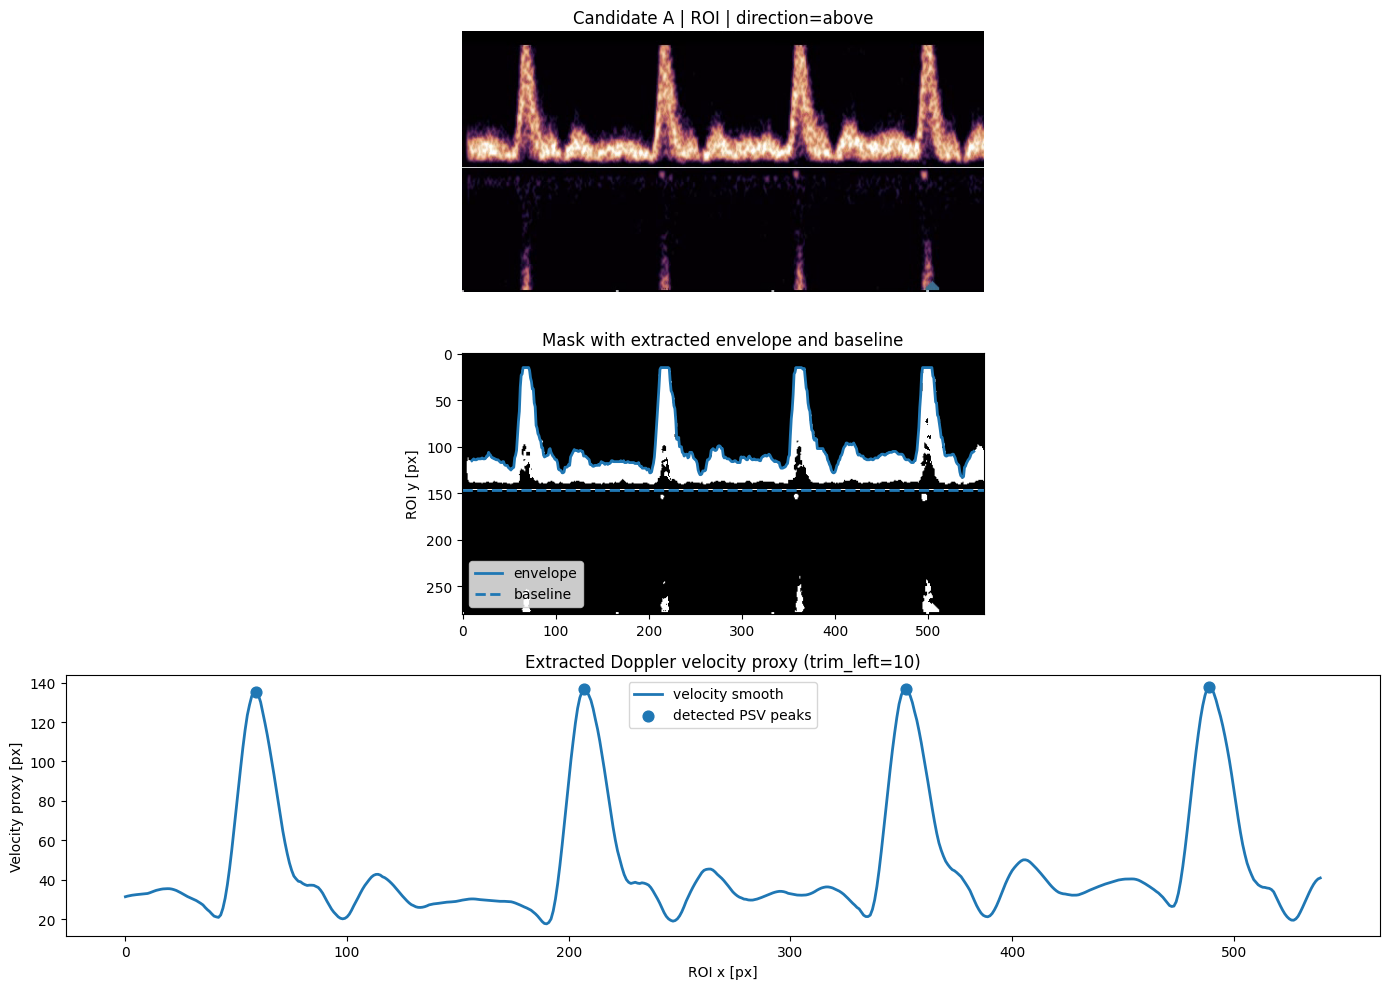

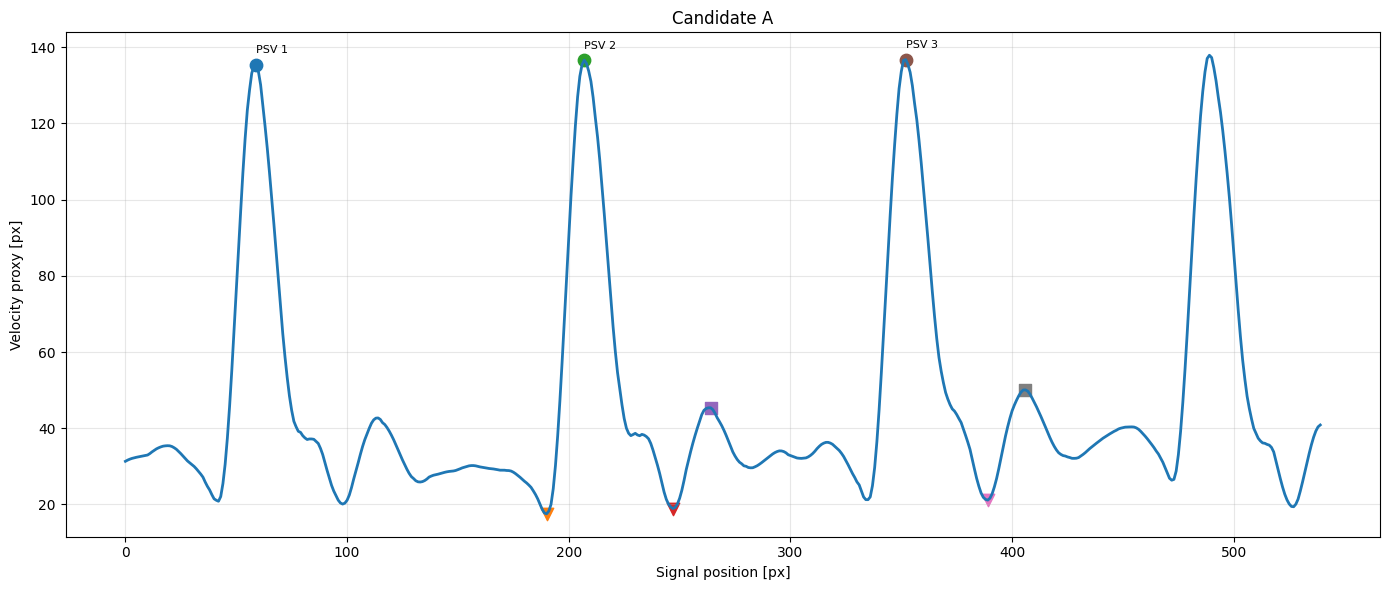

In [40]:
plot_doppler_extraction_result(result_a, title="Candidate A")

plot_beat_analysis(result_a, beat_df_a, title="Candidate A")

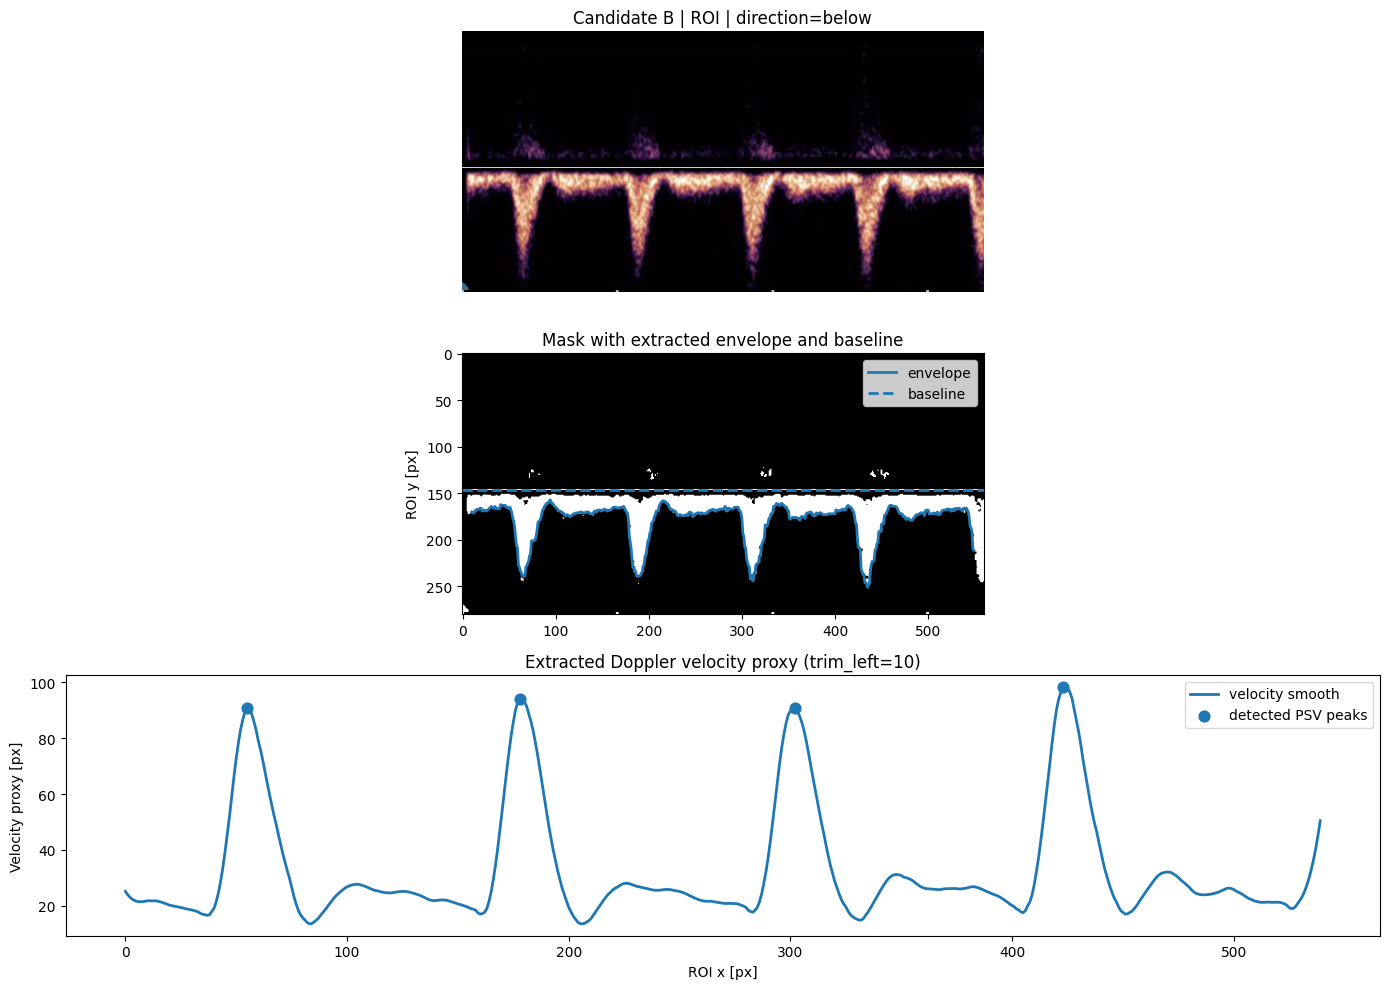

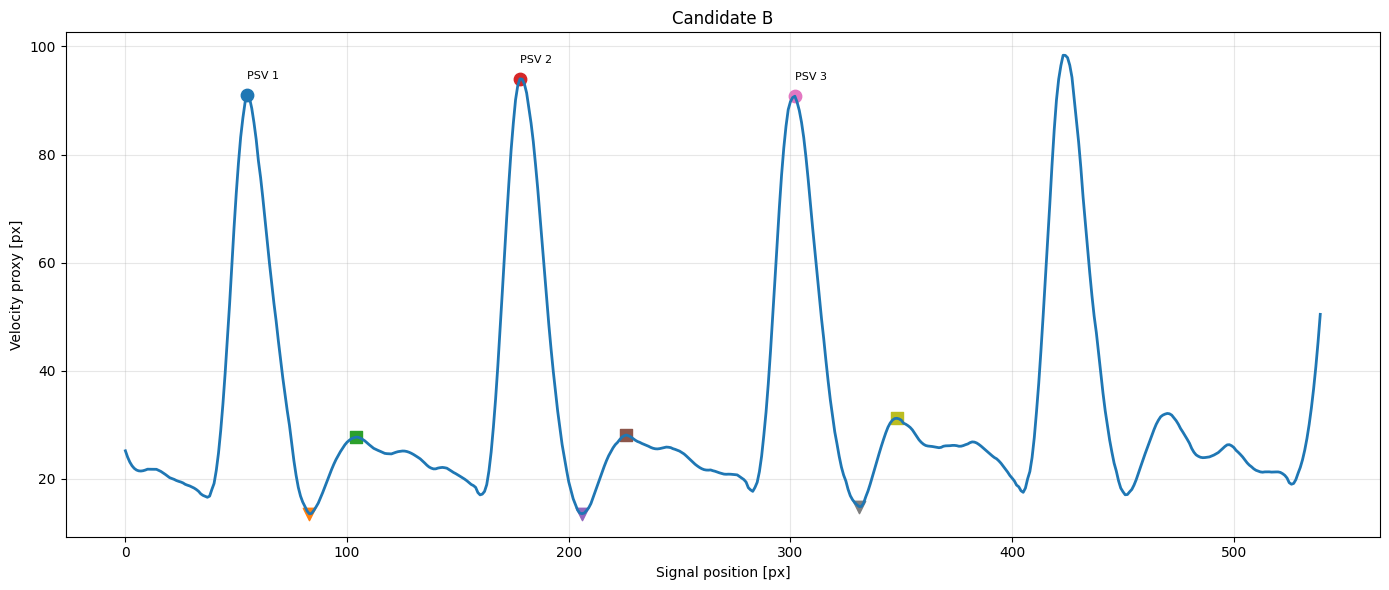

In [41]:
plot_doppler_extraction_result(result_b, title="Candidate B")

plot_beat_analysis(result_b, beat_df_b, title="Candidate B")

In [42]:
summary_all = pd.concat([summary_a, summary_b,], ignore_index=True)
summary_all

,label,n_total_beats,n_complete_beats,complete_fraction,mean_psv_px,std_psv_px,mean_edv_proxy_px,mean_ri_proxy,std_ri_proxy,mean_cycle_length_px,mean_time_to_valley_px,mean_time_to_secondary_peak_px,mean_secondary_to_psv_ratio
0,candidate_a,3,2,0.666667,136.652828,0.104483,20.039392,0.85336,0.011335,141.000000,38.500000,55.500000,0.349207
1,candidate_b,3,3,1.000000,91.911409,1.813791,14.004032,0.84754,0.010225,122.666667,28.333333,47.666667,0.315941


In [43]:
comparison_df = compare_recordings(summary_all)
comparison_df

,label,n_complete_beats,complete_fraction,mean_psv_px,mean_edv_proxy_px,mean_ri_proxy,mean_cycle_length_px,mean_secondary_to_psv_ratio
0,candidate_a,2,0.666667,136.652828,20.039392,0.85336,141.000000,0.349207
1,candidate_b,3,1.000000,91.911409,14.004032,0.84754,122.666667,0.315941


## Long-recording image quality-gate validation

In this section, the image-based Doppler pipeline is extended from short candidate frames to a long Doppler recording.

The main validation recording is:

- `candidate_long_quality_test.avi`

This recording is used as a quality-gate development case because it contains several clearly different signal-quality phases:

- an initial high-quality Doppler segment,
- gradual signal degradation caused by probe displacement,
- complete Doppler signal loss,
- a mechanical probe artifact,
- a silent/no-signal segment after the probe was removed.

Audio-based quality control from NB02 identified the usable Doppler segment as approximately:

- usable start: `0.592 s`
- usable end: `27.269 s`
- usable duration: `26.677 s`

The objective of this section is to test whether image-derived Doppler quality metrics can detect a similar usable segment directly from video frames.

At this stage, the goal is not audio-video synchronization. The goal is to develop image-side quality gates that can later be reused in NB03 together with the audio QC pipeline.

In [44]:
RECORDINGS_DIR = Path(r"D:\code\DopplerLab\ultrasound_recordings")

new_candidate_paths = {
    "candidate_long_quality_test": RECORDINGS_DIR / "candidate_long_quality_test.avi",
    "new_candidate_avi_1": RECORDINGS_DIR / "candidate_1.avi",
    "new_candidate_avi_2": RECORDINGS_DIR / "candidate_2.avi",
    "new_candidate_avi_3": RECORDINGS_DIR / "candidate_3.avi",
}

for name, path in new_candidate_paths.items():
    print(name, path, path.exists())

candidate_long_quality_test D:\code\DopplerLab\ultrasound_recordings\candidate_long_quality_test.avi True
new_candidate_avi_1 D:\code\DopplerLab\ultrasound_recordings\candidate_1.avi True
new_candidate_avi_2 D:\code\DopplerLab\ultrasound_recordings\candidate_2.avi True
new_candidate_avi_3 D:\code\DopplerLab\ultrasound_recordings\candidate_3.avi True


In [45]:
LONG_VIDEO_PATH = new_candidate_paths["candidate_long_quality_test"]

In [46]:
def show_video_frames_at_times(video_path, times_s, n_cols=4):
    """
    Visualize selected frames from a Doppler recording.

    Useful for manual inspection of signal quality, probe positioning,
    and recording artifacts.
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = []

    for t in times_s:
        frame_idx = int(round(t * fps))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()

        if not ok:
            frames.append(None)
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

    cap.release()

    n_images = len(frames)
    n_rows = int(np.ceil(n_images / n_cols))
    plt.figure(figsize=(4 * n_cols, 3.5 * n_rows))

    for i, (t, frame_rgb) in enumerate(zip(times_s, frames), start=1):
        plt.subplot(n_rows, n_cols, i)
        if frame_rgb is not None:
            plt.imshow(frame_rgb)

        plt.title(f"{t:.1f} s")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

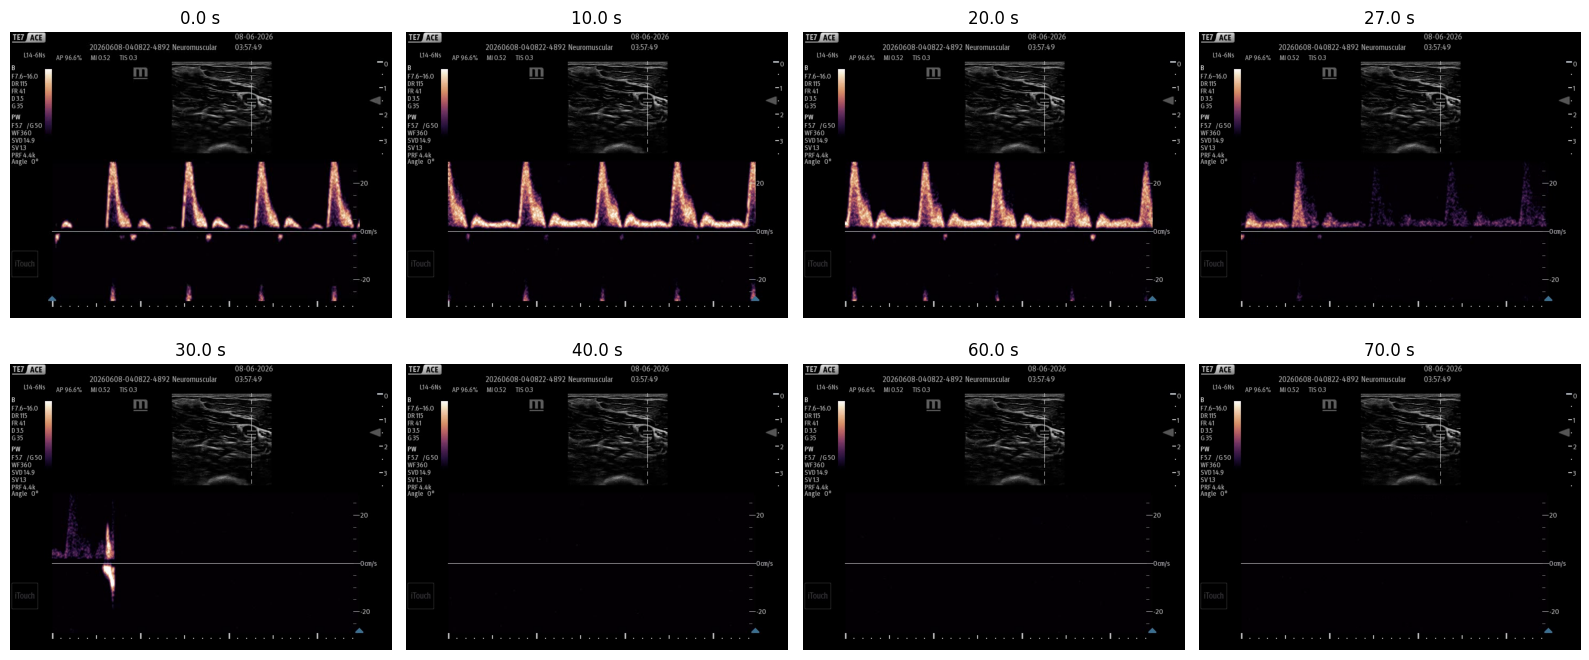

In [47]:
show_video_frames_at_times(video_path=LONG_VIDEO_PATH, times_s=[0, 10, 20, 27, 30, 40, 60, 70,])

## Candidate image quality metrics

In this section, several image-derived quality metrics are evaluated on selected frames from the long Doppler recording.

The objective is to identify which metrics are most sensitive to Doppler signal degradation and complete signal loss.

The tested metrics are intended for future development of an image-based quality gate and are not yet used for acceptance or rejection decisions.

In [48]:
def compute_frame_quality_metrics(
    frame_rgb,
    x_min=80,
    x_max=640,
    y_min=230,
    y_max=510,
    threshold=80,
    direction="auto",
    min_segment_length=5,
):
    """
    Compute image-derived quality metrics for a single Doppler frame.

    Measures signal coverage, envelope characteristics, and spectrum
    intensity to support image-based Doppler quality assessment.
    """
    roi = frame_rgb[y_min:y_max, x_min:x_max]
    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold
    row_sums = mask.sum(axis=1)
    baseline = int(np.argmax(row_sums))
    envelope, velocity_raw, selected_direction = extract_envelope_directional(
        mask=mask,
        baseline=baseline,
        direction=direction,
        min_segment_length=min_segment_length,
    )

    if selected_direction == "above":
        spectrum_mask = np.zeros_like(mask, dtype=bool)
        spectrum_mask[:baseline, :] = mask[:baseline, :]
    elif selected_direction == "below":
        spectrum_mask = np.zeros_like(mask, dtype=bool)
        spectrum_mask[baseline + 1:, :] = mask[baseline + 1:, :]
    else:
        raise ValueError("selected_direction must be 'above' or 'below'.")

    active_pixels = int(spectrum_mask.sum())
    total_pixels = int(spectrum_mask.size)
    active_pixel_fraction = (active_pixels / total_pixels)
    valid_envelope = ~np.isnan(envelope)

    envelope_coverage = (valid_envelope.mean())

    if np.any(valid_envelope):
        valid_velocity = velocity_raw[valid_envelope]
        mean_velocity_px = float(np.nanmean(valid_velocity))
        median_velocity_px = float(np.nanmedian(valid_velocity))
        p95_velocity_px = float(np.nanpercentile(valid_velocity, 95))
        envelope_area_px = float(np.nansum(valid_velocity))

    else:
        mean_velocity_px = 0.0
        median_velocity_px = 0.0
        p95_velocity_px = 0.0
        envelope_area_px = 0.0

    mean_signal_intensity = (float(gray[spectrum_mask].mean()) if active_pixels > 0 else 0.0)

    metrics = {
        "baseline": baseline,
        "direction": selected_direction,
        "active_pixels": active_pixels,
        "active_pixel_fraction": active_pixel_fraction,
        "envelope_coverage": envelope_coverage,
        "mean_velocity_px": mean_velocity_px,
        "median_velocity_px": median_velocity_px,
        "p95_velocity_px": p95_velocity_px,
        "envelope_area_px": envelope_area_px,
        "mean_signal_intensity": mean_signal_intensity,
    }

    return metrics

In [49]:
times_s = [0, 10, 20, 27, 30, 40, 60, 70]

quality_rows = []

cap = cv2.VideoCapture(str(LONG_VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
for t in times_s:
    frame_idx = int(round(t * fps))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    ok, frame = cap.read()

    if not ok:
        continue

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    metrics = compute_frame_quality_metrics(frame_rgb=frame_rgb, direction="auto", min_segment_length=5)
    metrics["time_s"] = t
    quality_rows.append(metrics)

cap.release()
quality_df = pd.DataFrame(quality_rows)
quality_df

,baseline,direction,active_pixels,active_pixel_fraction,envelope_coverage,mean_velocity_px,median_velocity_px,p95_velocity_px,envelope_area_px,mean_signal_intensity,time_s
0,146,above,10192,0.065000,0.546429,52.356209,33.0,131.0,16021.0,156.002453,0
1,146,above,14808,0.094439,0.958929,40.150838,23.0,128.0,21561.0,161.995948,10
2,146,above,16695,0.106473,0.950000,40.853383,25.0,124.0,21734.0,155.412579,20
3,146,above,2704,0.017245,0.223214,27.160000,19.0,84.0,3395.0,124.818047,27
4,146,below,696,0.004439,0.041071,33.521739,29.0,53.8,771.0,196.084770,30
5,146,below,22,0.000140,0.000000,0.000000,0.0,0.0,0.0,189.227273,40
6,146,below,22,0.000140,0.000000,0.000000,0.0,0.0,0.0,188.772727,60
7,146,below,22,0.000140,0.000000,0.000000,0.0,0.0,0.0,188.090909,70


In [50]:
def apply_frame_quality_gate(
    metrics,
    min_active_pixel_fraction=0.01,
    min_envelope_coverage=0.20,
    min_envelope_area_px=3000,
    min_p95_velocity_px=70,
):
    """
    Apply rule-based quality control to a single Doppler frame.

    Determines whether a frame contains sufficient Doppler signal
    for downstream waveform analysis.
    """
    reasons = []
    if metrics["active_pixel_fraction"] < min_active_pixel_fraction:
        reasons.append("low_active_pixel_fraction")
    if metrics["envelope_coverage"] < min_envelope_coverage:
        reasons.append("low_envelope_coverage")
    if metrics["envelope_area_px"] < min_envelope_area_px:
        reasons.append("low_envelope_area")
    if metrics["p95_velocity_px"] < min_p95_velocity_px:
        reasons.append("low_p95_velocity")

    is_usable_frame = len(reasons) == 0
    if is_usable_frame:
        quality_reason = "ok"
    else:
        quality_reason = ";".join(reasons)
    qc_result = {
        "is_usable_frame": is_usable_frame,
        "frame_quality_reason": quality_reason,
    }

    return qc_result

In [51]:
qc_rows = []

for _, row in quality_df.iterrows():
    qc = apply_frame_quality_gate(row)
    combined = row.to_dict()
    combined.update(qc)
    qc_rows.append(combined)

quality_qc_df = pd.DataFrame(qc_rows)

quality_qc_df[
    [
        "time_s",
        "active_pixel_fraction",
        "envelope_coverage",
        "envelope_area_px",
        "p95_velocity_px",
        "is_usable_frame",
        "frame_quality_reason",
    ]
]

,time_s,active_pixel_fraction,envelope_coverage,envelope_area_px,p95_velocity_px,is_usable_frame,frame_quality_reason
0,0,0.065000,0.546429,16021.0,131.0,True,ok
1,10,0.094439,0.958929,21561.0,128.0,True,ok
2,20,0.106473,0.950000,21734.0,124.0,True,ok
3,27,0.017245,0.223214,3395.0,84.0,True,ok
4,30,0.004439,0.041071,771.0,53.8,False,low_active_pixel_fraction;low_envelope_coverag...
5,40,0.000140,0.000000,0.0,0.0,False,low_active_pixel_fraction;low_envelope_coverag...
6,60,0.000140,0.000000,0.0,0.0,False,low_active_pixel_fraction;low_envelope_coverag...
7,70,0.000140,0.000000,0.0,0.0,False,low_active_pixel_fraction;low_envelope_coverag...


## Long-recording image quality scan

In this section, image-derived quality metrics are evaluated across an entire Doppler recording.

Frames are sampled at regular time intervals and processed using the image quality metrics developed earlier.

The objective is to determine whether image-based quality control can identify the same usable Doppler segment previously detected by the audio QC pipeline.

In [52]:
def run_image_quality_scan_for_video(video_path, sample_step_s=0.5):
    """
    Evaluate image quality across an entire Doppler recording.

    Samples video frames at regular intervals, computes image-quality
    metrics, and applies frame-level quality control.
    """
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_s = n_frames / fps
    rows = []
    sample_times = np.arange(0, duration_s, sample_step_s)

    for t in sample_times:
        frame_idx = int(round(t * fps))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()

        if not ok:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        metrics = compute_frame_quality_metrics(frame_rgb=frame_rgb, direction="auto", min_segment_length=5)
        qc = apply_frame_quality_gate(metrics)

        row = {}
        row["time_s"] = float(t)
        row.update(metrics)
        row.update(qc)
        rows.append(row)

    cap.release()
    quality_df = pd.DataFrame(rows)

    return quality_df

In [53]:
quality_scan_df = run_image_quality_scan_for_video(video_path=LONG_VIDEO_PATH, sample_step_s=0.5)
quality_scan_df.head()

,time_s,baseline,direction,active_pixels,active_pixel_fraction,envelope_coverage,mean_velocity_px,median_velocity_px,p95_velocity_px,envelope_area_px,mean_signal_intensity,is_usable_frame,frame_quality_reason
0,0.0,146,above,10192,0.065000,0.546429,52.356209,33.0,131.0,16021.0,156.002453,True,ok
1,0.5,146,above,10228,0.065230,0.544643,52.527869,33.0,131.0,16021.0,156.126711,True,ok
2,1.0,146,above,10228,0.065230,0.544643,52.527869,33.0,131.0,16021.0,156.127298,True,ok
3,1.5,146,above,10228,0.065230,0.544643,52.527869,33.0,131.0,16021.0,156.127298,True,ok
4,2.0,146,above,10208,0.065102,0.548214,52.254072,33.0,131.0,16042.0,156.234620,True,ok


In [54]:
quality_scan_df[["time_s", "is_usable_frame",]]

,time_s,is_usable_frame
0,0.0,True
1,0.5,True
2,1.0,True
3,1.5,True
4,2.0,True
...,...,...
148,74.0,False
149,74.5,False
150,75.0,False
151,75.5,False


In [55]:
len(quality_scan_df)

153

In [56]:
quality_scan_df["is_usable_frame"].value_counts()

is_usable_frame
False    98
True     55
Name: count, dtype: int64

In [57]:
quality_scan_df[["time_s","is_usable_frame"]].head(10)


,time_s,is_usable_frame
0,0.0,True
1,0.5,True
2,1.0,True
3,1.5,True
4,2.0,True
5,2.5,True
6,3.0,True
7,3.5,True
8,4.0,True
9,4.5,True


In [58]:
quality_scan_df[["time_s", "is_usable_frame"]].tail(10)

,time_s,is_usable_frame
143,71.5,False
144,72.0,False
145,72.5,False
146,73.0,False
147,73.5,False
148,74.0,False
149,74.5,False
150,75.0,False
151,75.5,False
152,76.0,False


In [59]:
def summarize_frame_quality_segment(quality_scan_df):
    """
    Summarize the usable Doppler segment identified by image quality control.

    Computes the start time, end time, duration, and fraction of the
    recording classified as usable.
    """
    if len(quality_scan_df) == 0:
        raise ValueError("quality_scan_df is empty.")

    usable_df = quality_scan_df[quality_scan_df["is_usable_frame"]].copy()

    total_duration_s = float(quality_scan_df["time_s"].max())

    n_total_frames = int(len(quality_scan_df))
    n_usable_frames = int(len(usable_df))

    if n_usable_frames == 0:
        return {
            "image_usable_start_s": np.nan,
            "image_usable_end_s": np.nan,
            "image_usable_duration_s": 0.0,
            "image_usable_fraction": 0.0,
            "n_total_sampled_frames": n_total_frames,
            "n_usable_frames": 0,
            "total_duration_s": total_duration_s,
        }

    image_usable_start_s = float(usable_df["time_s"].min())
    image_usable_end_s = float(usable_df["time_s"].max())
    sample_step_s = float(np.median(np.diff(quality_scan_df["time_s"])))

    image_usable_duration_s = float(n_usable_frames * sample_step_s)
    image_usable_fraction = float(image_usable_duration_s / total_duration_s)

    summary = {
        "image_usable_start_s": image_usable_start_s,
        "image_usable_end_s": image_usable_end_s,
        "image_usable_duration_s": image_usable_duration_s,
        "image_usable_fraction": image_usable_fraction,
        "n_total_sampled_frames": n_total_frames,
        "n_usable_frames": n_usable_frames,
        "total_duration_s": total_duration_s,
    }

    return summary

In [60]:
image_qc_summary = summarize_frame_quality_segment(quality_scan_df)
image_qc_summary

{'image_usable_start_s': 0.0,
 'image_usable_end_s': 27.0,
 'image_usable_duration_s': 27.5,
 'image_usable_fraction': 0.3618421052631579,
 'n_total_sampled_frames': 153,
 'n_usable_frames': 55,
 'total_duration_s': 76.0}

## Visualization of image quality metrics

In this section, image-derived quality metrics are visualized across the entire Doppler recording.

The objective is to inspect how the quality metrics evolve during signal degradation and complete Doppler signal loss.

These visualizations are used to validate the behavior of the image quality gate before it is reused in later notebooks.

In [61]:
def plot_image_quality_scan(quality_scan_df):
    """
    Visualize image quality metrics across a long Doppler recording.
    """

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    time_s = quality_scan_df["time_s"]

    axes[0].plot(time_s, quality_scan_df["active_pixel_fraction"], linewidth=2)
    axes[0].set_ylabel("active_pixel_fraction")
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(time_s, quality_scan_df["envelope_coverage"], linewidth=2)
    axes[1].set_ylabel("envelope_coverage")
    axes[1].grid(alpha=0.3)
    
    axes[2].plot(time_s, quality_scan_df["envelope_area_px"], linewidth=2)
    axes[2].set_ylabel("envelope_area_px")
    axes[2].grid(alpha=0.3)

    usable = (quality_scan_df["is_usable_frame"].astype(int))

    axes[3].step(time_s, usable, where="mid", linewidth=2)
    axes[3].set_ylabel("usable")
    axes[3].set_xlabel("time [s]")
    axes[3].set_ylim(-0.1, 1.1)
    axes[3].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

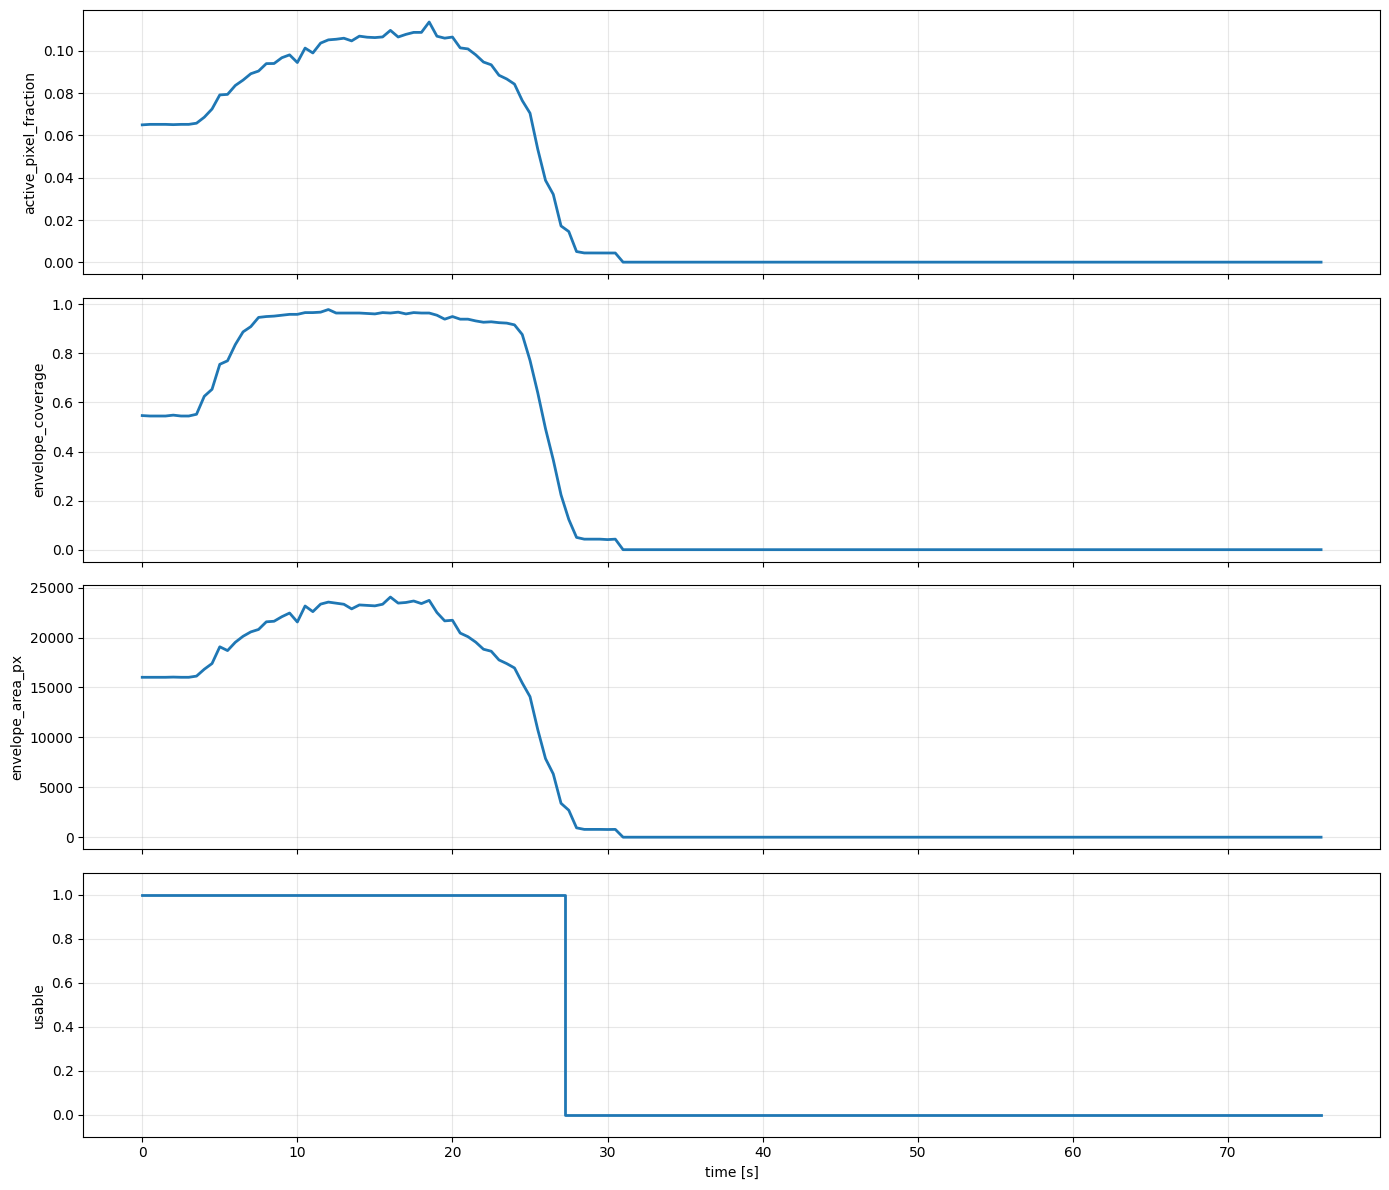

In [62]:
plot_image_quality_scan(quality_scan_df)

## Long-recording validation summary

The image-based quality-control pipeline was evaluated on a long Doppler recording containing progressive signal degradation and complete signal loss.

Image-derived quality metrics showed a consistent decline during probe displacement and converged to near-zero values after Doppler signal loss.

The resulting image-derived usable segment was estimated as approximately 0-27 seconds, which was consistent with the operator observation and with the independently developed audio quality-control pipeline.

These results suggest that the image-based quality gate is sufficiently robust to identify usable Doppler segments before downstream waveform and morphology analysis.